# Synthetic Datasets: Plots of Utility and Group Fairness Metrics

Author: Ilse Harmers \
Last modified: March 26, 2026

In [1]:
# Importing libraries.
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
from matplotlib import ticker
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

import matplotlib
params = {'axes.titlesize':'20',
          'xtick.labelsize':'18',
          'ytick.labelsize':'18',
          'font.size':'18',
          'legend.fontsize':'medium',
          'lines.linewidth':'2.0',
          'font.weight':'normal',
          'lines.markersize':'5',
          'text.latex.preamble': r'\usepackage{amsfonts}',
          }
matplotlib.rcParams.update(params)
plt.rcParams["mathtext.fontset"] = "cm"
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

## Initialization

In [2]:
# Initializing the values for epsilon, the labels for the different metrics, the weights used in the guidelines and our functions. 
epsi = [1, 2, 5, 8]
metrics = ["acc", "prec", "recall", "auroc", "dem", "dis", "eqopp"]
weights = [1, 1, 0]   # 1: auroc; 1: group fairness; 0: privacy

def synth_selection(models, epsilon, dataset, weights = [1, 1, 1]):
    """This function returns the rankings of the 'best' synthetic datasets out of all our models for an epsilon 'epsilon'. 'Best' refers to the 
    datasets which are best able to balance classifier utility (AUROC), classifier group fairness (demographic parity, disparate impact and equal 
    opportunity) and privacy (DCR and NNDR). The rankings are based on a point-based ranking scheme where the 'best' results for each of the metrics 
    are ranked from first through last place. This function also returns the (un)processed utility and fairness results and the privacy results
    of the synthetic datasets. 

    The total number of synthetic datasets for each model is hard-coded as 15, which should be modified in cases where this is not true.
    
    models [list]: folder locations of the GANs' synthetic datasets
    epsilon [integer]: epsilon value 
    dataset [string]: folder name of the synthetic datasets; can be set to "adult", "bank-marketing" or "credit-card-default"
    weights [list]: utility, fairness and privacy weights assigned to the AUROC, classifier group fairness and privacy points of the synthetic datasets
    """

    metrics = ["acc", "auroc", "dem", "dis", "eqopp"]
    results_eps_avg = {}
    results_eps_avg_std = {}
    privacy_results = {}
    
    for mod in models:
        if mod == "TabFair":
            file_path = f"./synthetic-datasets_{mod}/{dataset}/"

            # Importing synthetic datasets' results as pandas DataFrames.
            run1 = pd.read_csv(file_path + f"run1/results_run1.csv", index_col = 0, na_values = "np.nan")
            run2 = pd.read_csv(file_path + f"run2/results_run2.csv", index_col = 0, na_values = "np.nan")
            run3 = pd.read_csv(file_path + f"run3/results_run3.csv", index_col = 0, na_values = "np.nan")
            run4 = pd.read_csv(file_path + f"run4/results_run4.csv", index_col = 0, na_values = "np.nan")
            run5 = pd.read_csv(file_path + f"run5/results_run5.csv", index_col = 0, na_values = "np.nan")
        else:
            file_path = f"./synthetic-datasets_{mod}_B=512/{dataset}/"

            # Importing synthetic datasets' results as pandas DataFrames.
            run1 = pd.read_csv(file_path + f"epsi_{epsilon}/run1/results_epsi-{epsilon}_run1.csv", index_col = 0, na_values = "np.nan")
            run2 = pd.read_csv(file_path + f"epsi_{epsilon}/run2/results_epsi-{epsilon}_run2.csv", index_col = 0, na_values = "np.nan")
            run3 = pd.read_csv(file_path + f"epsi_{epsilon}/run3/results_epsi-{epsilon}_run3.csv", index_col = 0, na_values = "np.nan")
            run4 = pd.read_csv(file_path + f"epsi_{epsilon}/run4/results_epsi-{epsilon}_run4.csv", index_col = 0, na_values = "np.nan")
            run5 = pd.read_csv(file_path + f"epsi_{epsilon}/run5/results_epsi-{epsilon}_run5.csv", index_col = 0, na_values = "np.nan")
        
        # Concatenating the results into one DataFrame. 
        results = pd.concat([run1.reset_index(drop = True), run2.reset_index(drop = True),
                             run3.reset_index(drop = True), run4.reset_index(drop = True),
                             run5.reset_index(drop = True)], axis = 0)

        eps_avg = {}
        eps_avg_std = {}

        dem_mean = np.nanmean(abs(results[["dem-parity"]]), axis = 1)
        eps_avg["dem-parity"] = {f"sample{i + 1}-{mod}": dem_mean[i] for i in range(len(dem_mean))}
        eps_avg_std["dem-parity"] = {f"sample{i + 1}-{mod}": "NaN" for i in range(len(dem_mean))}
        
        dis_mean = np.nanmean(results[["dis-impact"]], axis = 1)
        eps_avg["dis-impact"] = {f"sample{i + 1}-{mod}": dis_mean[i] for i in range(len(dis_mean))}
        eps_avg_std["dis-impact"] = {f"sample{i + 1}-{mod}": "NaN" for i in range(len(dis_mean))}
            
        for m in metrics:
            if m == "dis":   # averaging over 'regular' values
                m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
                m_std = np.nanstd(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
            else:   # averaging over absolute values
                m_mean = np.nanmean(abs(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]), axis = 1)
                m_std = np.nanstd(abs(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]), axis = 1)
            eps_avg[m] = {f"sample{i + 1}-{mod}": m_mean[i] for i in range(len(m_mean))}
            eps_avg_std[m] = {f"sample{i + 1}-{mod}": m_std[i] for i in range(len(m_std))}

        results_eps_avg[mod] = pd.DataFrame(eps_avg)
        results_eps_avg_std[mod] = pd.DataFrame(eps_avg_std)

        new_index = [f"sample{i + 1}-{mod}" for i in range(len(m_mean))]
        if mod == "TabFair":
            privacy_results[mod] = pd.read_csv(file_path + f"priv-results.csv", index_col = 0).T
        else:
            privacy_results[mod] = pd.read_csv(file_path + f"priv-results_epsi-{epsilon}.csv", index_col = 0).T
        privacy_results[mod].rename(index = {f"sample{i + 1}": f"sample{i + 1}-{mod}" for i in range(len(m_mean))}, inplace = True) 

    results_avg = pd.concat([results_eps_avg[k] for k in results_eps_avg.keys()], axis = 0)
    results_avg_std = pd.concat([results_eps_avg_std[k] for k in results_eps_avg_std.keys()], axis = 0)
    priv_results = pd.concat([privacy_results[k] for k in privacy_results.keys()], axis = 0)
    
    # Rankings for classfiers' utility.
    points_auroc = pd.Series(range(15*len(models), 0, -1), index = results_avg.sort_values(by = ["auroc"]).index)

    # Rankings for classfiers' group fairness.
    points_dem = pd.Series(range(1, 15*len(models) + 1), index = results_avg.sort_values(by = ["dem"]).index)
    points_eqopp = pd.Series(range(1, 15*len(models) + 1), index = results_avg.sort_values(by = ["eqopp"]).index)
    # We set all DI values in the fair/green zone (i.e., between 0.0 - 0.45) to 1 to single these out, assuming that no DI value is exactly equal to 1.
    points_dis = results_avg["dis"].copy()
    points_dis.loc[(points_dis >= 0) & (points_dis <= 0.45)] = 1
    # For DI values in the red zones (i.e., smaller than 0 or greater than 0.45), we compute their distance to the green zone. 
    # Smaller distances to the green zone are fairer. 
    points_dis.loc[(points_dis > 0.45) & (points_dis != 1.0)] = points_dis - 0.45
    points_dis.loc[points_dis < 0] = abs(points_dis)
    points_dis[points_dis.loc[points_dis != 1.0].sort_values().index] = range(2, 2 + len(points_dis.loc[points_dis != 1.0].sort_values()))
    points_gpfair = (points_dem + points_dis + points_eqopp) / 3

    # Rankings for synthetic datasets' privacy.
    points_NNDR = pd.Series(range(15*len(models), 0, -1), index = priv_results.sort_values(by = ["NNDR"]).index)
    points_DCR = pd.Series(range(15*len(models), 0, -1), index = priv_results.sort_values(by = ["DCR"]).index)
    points_priv = (points_NNDR + points_DCR) / 2

    final_srt = (weights[0]*points_auroc + weights[1]*points_gpfair + weights[2]*points_priv).sort_values()

    return (results, results_avg, results_avg_std, privacy_results, final_srt)

def results(model, epsilons, dataset, weights):
    """This function returns the 'best' synthetic dataset out of all our runs for each epsilon value in 'epsilons'. 'Best' refers to the dataset which 
    is best able to balance classifier utility (AUROC), classifier group fairness (demographic parity, disparate impact and equal opportunity) and 
    privacy (DCR and NNDR). This function also returns the (un)processed utility and fairness results and the privacy results of the 'best' 
    synthetic datasets.

    model [list]: model name of GAN, recorded in a single-entry list
    epsilons [list]: epsilon values during GAN training; if GAN has no privacy constraints, set epsilons = [0]
    dataset [string]: folder name of the synthetic datasets; can be set to "adult", "bank-marketing" or "credit-card-default"
    weights [list]: utility, fairness and privacy weights assigned to the AUROC, classifier group fairness and privacy points of the synthetic datasets
    """
    
    results_mean = {}
    results_std = {}
    results_org = {}
    results_priv = {}
    for e in epsilons:
        (results, results_avg, results_avg_std, privacy_results, final_srt) = synth_selection(model, epsilon = e, dataset = dataset, weights = weights)
        if e != 0:
            print(f"Epsilon = {e}")
        try:
            index = int(final_srt.index[0][6:8]) - 1
        except  ValueError:
            index = int(final_srt.index[0][6:7]) - 1
        print(f"Sample {index + 1}")   # best synthetic dataset
        # Privacy metrics of the best synthetic dataset.
        print("DCR:", privacy_results[model[0]].loc[final_srt.index[0]][0])
        print("NNDR:", privacy_results[model[0]].loc[final_srt.index[0]][1])
        print()
        # Dataset utility metrics of the best synthetic dataset.
        if model[0] == "TabFair":
            file_path = f"./synthetic-datasets_{model[0]}/{dataset}/"
            dat_util = pd.read_csv(file_path + "dataset-utility-results_mean.csv", index_col = 0)
            dat_util_std = pd.read_csv(file_path + "dataset-utility-results_std.csv", index_col = 0)
        else:
            file_path = f"./synthetic-datasets_{model[0]}_B=512/{dataset}/"
            dat_util = pd.read_csv(file_path + f"dataset-utility-results_mean_epsi-{e}.csv", index_col = 0)
            dat_util_std = pd.read_csv(file_path + f"dataset-utility-results_std_epsi-{e}.csv", index_col = 0)
        print(dat_util.iloc[index])
        print(dat_util_std.iloc[index])
        if e != 0 and e < 8:
            print()
        if e == 0:
            return (pd.concat([results_avg.loc[final_srt.index[0]], results_avg_std.loc[final_srt.index[0]]], axis = 1, 
                             ignore_index = True).T.rename({0: "mean", 1: "std"}), pd.DataFrame(results.iloc[index]).T,
            pd.DataFrame({"DCR": [privacy_results[model[0]].loc[final_srt.index[0]][0]], 
                          "NNDR": [privacy_results[model[0]].loc[final_srt.index[0]][1]]}))
        else:      
            results_mean[f"epsi_{e}"] = results_avg.loc[final_srt.index[0]]
            results_std[f"epsi_{e}"] = results_avg_std.loc[final_srt.index[0]]
            results_org[f"epsi_{e}"] = results.iloc[index]
            results_priv[f"epsi_{e}"] = {"DCR": privacy_results[model[0]].loc[final_srt.index[0]][0], 
                                         "NNDR": privacy_results[model[0]].loc[final_srt.index[0]][1]}

    results_mean = pd.concat([results_mean[i] for i in [f"epsi_{e}" for e in epsilons]], axis = 1, 
                             ignore_index = True).T.rename(index = {i: f"epsi_{epsilons[i]}" for i in range(len(epsilons))})
    results_std = pd.concat([results_std[i] for i in [f"epsi_{e}" for e in epsilons]], axis = 1, 
                             ignore_index = True).T.rename(index = {i: f"epsi_{epsilons[i]}" for i in range(len(epsilons))})
    results_org = pd.concat([results_org[i] for i in [f"epsi_{e}" for e in epsilons]], axis = 1, 
                             ignore_index = True).T.rename(index = {i: f"epsi_{epsilons[i]}" for i in range(len(epsilons))})
    results_priv = pd.DataFrame(results_priv)
    
    return results_mean, results_std, results_org, results_priv

def metrics_average(adult_samp, bank_samp, credit_samp, epsi = epsi):
    """This function computes the average classifier utility and group fairness results of the Adult, Bank and Credit 'best' synthetic datasets for
    each epsilon value. Both the means and standard deviations of the averaged results are returned."""
    
    avg_met_results = {}
    avg_met_results_std = {}
    for e in range(len(epsi)):
        eps_avg = {}
        eps_avg_std = {}
        for m in metrics:
            if m != "dis":   # averaging over absolute values
                avg = [abs(adult_samp.iloc[e][[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]), abs(bank_samp.iloc[e][[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]),
                       abs(credit_samp.iloc[e][[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]])]
            else:   # averaging over 'regular' values
                avg = [adult_samp.iloc[e][[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], bank_samp.iloc[e][[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]],
                       credit_samp.iloc[e][[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]]
            eps_avg[m] = np.nanmean(avg)
            eps_avg_std[m] = np.nanstd(avg)
        avg_met_results[f"epsi_{epsi[e]}"] = eps_avg 
        avg_met_results_std[f"epsi_{epsi[e]}"] = eps_avg_std

    avg_met_results = pd.DataFrame(avg_met_results).T
    avg_met_results_std = pd.DataFrame(avg_met_results_std).T

    return avg_met_results, avg_met_results_std

## Adult Dataset (Real)

In [3]:
adult_results_real = pd.read_csv("./train-test-datasets/adult/results_real.csv", index_col = 0)

results_real_avg = {}
for m in metrics:
    if m == "dis":   # averaging over 'regular' values
        m_mean = adult_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().mean()
        m_std = adult_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().std(ddof = 0)
    else:   # averaging over absolute values
        m_mean = abs(adult_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().mean()
        m_std = abs(adult_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().std(ddof = 0)
    results_real_avg[m] = (m_mean, m_std)

adult_results = pd.concat([adult_results_real[["dem-parity", "dis-impact"]].reset_index(drop = True),
                           pd.DataFrame(results_real_avg).reset_index(drop = True)], 
                           axis = 1).rename(index = {0: "mean", 1: "std"})

In [4]:
adult_results

,dem-parity,dis-impact,acc,prec,recall,auroc,dem,dis,eqopp
mean,0.223423,-0.556448,95.341809,89.795789,88.296220,0.927752,0.218255,-0.573351,0.252604
std,NaN,NaN,1.034073,3.331241,1.467187,0.011739,0.006818,0.021310,0.037947


In [5]:
# No preprocessing applied.

adult_real_old = pd.read_csv("../train-test-datasets/adult/results_real.csv", index_col = 0)

results_real_avg = {}
for m in metrics:
    if m == "dis":   # averaging over 'regular' values
        m_mean = adult_real_old[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().mean()
        m_std = adult_real_old[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().std(ddof = 0)
    else:   # averaging over absolute values
        m_mean = abs(adult_real_old[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().mean()
        m_std = abs(adult_real_old[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().std(ddof = 0)
    results_real_avg[m] = (m_mean, m_std)

adult_nop_results = pd.concat([adult_real_old[["dem-parity", "dis-impact"]].reset_index(drop = True),
                           pd.DataFrame(results_real_avg).reset_index(drop = True)], 
                           axis = 1).rename(index = {0: "mean", 1: "std"})

In [6]:
adult_nop_results

,dem-parity,dis-impact,acc,prec,recall,auroc,dem,dis,eqopp
mean,0.197423,-0.436622,84.370739,73.136606,61.000000,0.766700,0.174819,-0.447667,0.047741
std,NaN,NaN,0.282207,1.440525,0.993996,0.001913,0.005213,0.016824,0.019835


## Synthetic Adult Dataset (TabFairGAN)

In [7]:
# TabFairGAN.
model = ["TabFair"]
adult_tabfair_results, TF_sample_adult, TF_priv_adult = results(model = model, epsilons = [0], dataset = "adult", weights = weights)

Sample 5
DCR: 0.0
NNDR: 0.0

KS     0.069884
TVD    0.011592
WSS    0.030333
Name: sample5, dtype: float64
KS     0.025683
TVD    0.003446
WSS    0.012788
Name: sample5, dtype: float64


In [8]:
adult_tabfair_old = pd.read_csv("../saved-GAN-results/adult/adult_tabfair_results.csv", index_col = 0)
adult_tabfair_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
mean,0.097236,-0.142449,81.978994,0.765658,0.152193,-0.294562,0.046422
std,NaN,NaN,0.870116,0.010209,0.013648,0.060765,0.013133


In [9]:
adult_tabfair_results

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
mean,0.105269,-0.191966,92.655242,0.892437,0.159011,-0.392843,0.100006
std,NaN,NaN,0.189854,0.004743,0.006677,0.016364,0.017955


## Synthetic Adult Dataset (DP-GAN)

In [10]:
# DP-GAN.
model = ["DP-GAN"]
adult_results_DP, adult_results_DP_std, adult_DP_samples, DP_priv_adult = results(model = model, epsilons = epsi, dataset = "adult", weights = weights)

Epsilon = 1
Sample 13
DCR: 0.2644229094329827
NNDR: 0.5530322434360941

KS     0.344517
TVD    0.344708
WSS    0.128256
Name: sample13, dtype: float64
KS     0.183843
TVD    0.113526
WSS    0.088796
Name: sample13, dtype: float64

Epsilon = 2
Sample 4
DCR: 0.1234995845253034
NNDR: 0.5270056508561413

KS     0.337972
TVD    0.152124
WSS    0.081347
Name: sample4, dtype: float64
KS     0.114936
TVD    0.136596
WSS    0.059896
Name: sample4, dtype: float64

Epsilon = 5
Sample 3
DCR: 0.0800701107507255
NNDR: 0.4577233714761113

KS     0.296802
TVD    0.106518
WSS    0.072042
Name: sample3, dtype: float64
KS     0.197472
TVD    0.080001
WSS    0.073541
Name: sample3, dtype: float64

Epsilon = 8
Sample 6
DCR: 0.1149312588595204
NNDR: 0.5924321282161253

KS     0.284711
TVD    0.119589
WSS    0.048693
Name: sample6, dtype: float64
KS     0.150459
TVD    0.069768
WSS    0.028036
Name: sample6, dtype: float64


In [11]:
adult_DP_old = pd.read_csv("../saved-GAN-results/adult/adult_results_DP.csv", index_col = 0)
adult_DP_old_std = pd.read_csv("../saved-GAN-results/adult/adult_results_DP_std.csv", index_col = 0)
adult_DP_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.017446,0.162316,59.561452,0.627383,0.230374,-0.192728,0.159096
epsi_2,0.144321,-0.474803,77.280265,0.571980,0.037326,-0.425178,0.051990
epsi_5,0.023749,0.104282,77.361341,0.652226,0.071327,-0.147355,0.011819
epsi_8,0.251841,-0.750918,78.208955,0.610441,0.063299,-0.366180,0.067692


In [12]:
adult_results_DP#, adult_results_DP_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.021005,0.254081,55.621891,0.705052,0.213135,-0.098424,0.083120
epsi_2,0.110324,0.750531,74.619495,0.692763,0.064911,0.013220,0.157656
epsi_5,0.005617,0.176904,89.076838,0.835292,0.168560,-0.429828,0.154655
epsi_8,0.243382,-0.789876,82.049014,0.622717,0.063004,-0.430097,0.109081


## Synthetic Adult Dataset (DP-CTGAN)

In [13]:
# DP-CTGAN.
model = ["DPCTGAN"]
adult_results_DPC, adult_results_DPC_std, adult_DPC_samples, CT_priv_adult = results(model = model, epsilons = epsi, dataset = "adult", 
                                                                                     weights = weights)

Epsilon = 1
Sample 8
DCR: 0.171568638998563
NNDR: 0.5451999661210448

KS     0.329170
TVD    0.356425
WSS    0.082288
Name: sample8, dtype: float64
KS     0.168720
TVD    0.222014
WSS    0.067031
Name: sample8, dtype: float64

Epsilon = 2
Sample 8
DCR: 0.0697114391892549
NNDR: 0.3651448975662199

KS     0.376880
TVD    0.165122
WSS    0.064052
Name: sample8, dtype: float64
KS     0.173339
TVD    0.116304
WSS    0.044322
Name: sample8, dtype: float64

Epsilon = 5
Sample 9
DCR: 0.1117637101718729
NNDR: 0.4484325073034684



C:\Users\ilseh\AppData\Local\Temp\ipykernel_13008\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


KS     0.359842
TVD    0.112136
WSS    0.072480
Name: sample9, dtype: float64
KS     0.224125
TVD    0.114337
WSS    0.051554
Name: sample9, dtype: float64

Epsilon = 8
Sample 3
DCR: 0.0918429146085592
NNDR: 0.5229597209762348

KS     0.313050
TVD    0.113943
WSS    0.070669
Name: sample3, dtype: float64
KS     0.167837
TVD    0.084253
WSS    0.059588
Name: sample3, dtype: float64


In [14]:
adult_DPC_old = pd.read_csv("../saved-GAN-results/adult/adult_results_DPC.csv", index_col = 0)
adult_DPC_old_std = pd.read_csv("../saved-GAN-results/adult/adult_results_DPC_std.csv", index_col = 0)
adult_DPC_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.140410,0.019628,58.610650,0.677454,0.271799,-0.197702,0.130867
epsi_2,0.258288,-0.644581,79.262945,0.618320,0.076405,-0.487676,0.058193
epsi_5,0.194196,-0.348120,81.470426,0.677342,0.121236,-0.502737,0.080562
epsi_8,0.129177,-0.412706,79.594619,0.639789,0.071857,-0.317469,0.021197


In [15]:
adult_results_DPC#, adult_results_DPC_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.001297,0.530332,78.581168,0.500372,0.000312,0.022690,0.002554
epsi_2,0.175634,-0.345386,88.804128,0.768725,0.153377,-0.611630,0.234181
epsi_5,0.218968,-0.518208,91.041091,0.830926,0.159172,-0.509178,0.078569
epsi_8,0.361267,-0.621432,89.508015,0.875700,0.252384,-0.547832,0.293385


## Synthetic Adult Dataset (Fair DP-GAN with Demographic Parity Loss)

In [16]:
# Fair DP-GAN (dem).
model = ["FairDP-GAN(dem)"]
adult_results_dem, adult_results_dem_std, adult_dem_samples, dem_priv_adult = results(model = model, epsilons = epsi, dataset = "adult",
                                                                                      weights = weights)

Epsilon = 1
Sample 7
DCR: 1.1503861869083298
NNDR: 0.752011879642941

KS     0.640788
TVD    0.334615
WSS    0.150137
Name: sample7, dtype: float64
KS     0.230100
TVD    0.167287
WSS    0.126905
Name: sample7, dtype: float64

Epsilon = 2
Sample 11
DCR: 0.0759109851392097
NNDR: 0.383379598855436

KS     0.222506
TVD    0.118995
WSS    0.057483
Name: sample11, dtype: float64
KS     0.103113
TVD    0.066308
WSS    0.046962
Name: sample11, dtype: float64

Epsilon = 5
Sample 12
DCR: 0.0899265778252651
NNDR: 0.3900025475543079

KS     0.361904
TVD    0.112261
WSS    0.068427
Name: sample12, dtype: float64
KS     0.124514
TVD    0.087632
WSS    0.043307
Name: sample12, dtype: float64

Epsilon = 8
Sample 12
DCR: 0.0877597002773048
NNDR: 0.5630605570345966

KS     0.283932
TVD    0.109683
WSS    0.066533
Name: sample12, dtype: float64
KS     0.098624
TVD    0.085362
WSS    0.066782
Name: sample12, dtype: float64


In [17]:
adult_dem_old = pd.read_csv("../saved-GAN-results/adult/adult_results_dem.csv", index_col = 0)
adult_dem_old_std = pd.read_csv("../saved-GAN-results/adult/adult_results_dem_std.csv", index_col = 0)
adult_dem_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.149889,-0.061434,54.943800,0.650480,0.310911,-0.230361,0.200952
epsi_2,0.037449,0.013106,75.072784,0.610234,0.168311,-0.577661,0.234286
epsi_5,0.025892,0.330952,74.995393,0.603268,0.022256,0.365605,0.110061
epsi_8,0.306094,-0.651060,81.098213,0.713718,0.151471,-0.416745,0.070305


In [18]:
adult_results_dem#, adult_results_dem_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.150802,0.583326,58.024691,0.530860,0.014165,0.194577,0.139138
epsi_2,0.011520,0.252132,73.569191,0.554409,0.056882,-0.141158,0.174885
epsi_5,0.113431,-0.395288,79.963147,0.588705,0.027187,-0.119683,0.021551
epsi_8,0.245790,-0.701819,84.031693,0.658399,0.040654,-0.160859,0.130188


## Synthetic Adult Dataset (Fair DP-GAN with Disparate Impact Loss)

In [19]:
# Fair DP-GAN (dis).
model = ["FairDP-GAN(dis)"]
adult_results_dis, adult_results_dis_std, adult_dis_samples, dis_priv_adult = results(model = model, epsilons = epsi, dataset = "adult",
                                                                                      weights = weights)

Epsilon = 1
Sample 14
DCR: 0.5281237121157828
NNDR: 0.6545486918904413

KS     0.547033
TVD    0.401032
WSS    0.147771
Name: sample14, dtype: float64
KS     0.217885
TVD    0.178594
WSS    0.120301
Name: sample14, dtype: float64

Epsilon = 2
Sample 13
DCR: 0.101974610647142
NNDR: 0.3927049850138941

KS     0.286895
TVD    0.107351
WSS    0.114437
Name: sample13, dtype: float64
KS     0.072305
TVD    0.089068
WSS    0.082057
Name: sample13, dtype: float64

Epsilon = 5
Sample 12
DCR: 0.0830283931665154
NNDR: 0.6573781700939221

KS     0.207132
TVD    0.131862
WSS    0.065507
Name: sample12, dtype: float64
KS     0.143859
TVD    0.137993
WSS    0.061073
Name: sample12, dtype: float64

Epsilon = 8
Sample 1
DCR: 0.0811878865049184
NNDR: 0.3923984842867487

KS     0.313680
TVD    0.116310
WSS    0.081637
Name: sample1, dtype: float64
KS     0.189288
TVD    0.096981
WSS    0.075307
Name: sample1, dtype: float64


In [20]:
adult_dis_old = pd.read_csv("../saved-GAN-results/adult/adult_results_dis.csv", index_col = 0)
adult_dis_old_std = pd.read_csv("../saved-GAN-results/adult/adult_results_dis_std.csv", index_col = 0)
adult_dis_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.068549,0.071951,74.814815,0.627845,0.070872,-0.128227,0.032112
epsi_2,0.055242,-0.099757,77.416621,0.582732,0.049976,-0.386938,0.019463
epsi_5,0.226550,-0.490745,77.833057,0.625351,0.037492,-0.032201,0.086764
epsi_8,0.096909,-0.307015,77.453473,0.586704,0.026601,-0.135633,0.091355


In [21]:
adult_results_dis#, adult_results_dis_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.303255,-0.271350,72.662613,0.639323,0.110786,-0.147296,0.073852
epsi_2,0.041626,0.062887,75.728764,0.660638,0.028754,0.277852,0.130266
epsi_5,0.256703,-0.642690,83.427308,0.685998,0.110229,-0.442225,0.103780
epsi_8,0.263534,-0.665217,89.327437,0.866000,0.225120,-0.516675,0.211560


## Synthetic Adult Dataset (Fair DP-GAN with All Fair Losses)

In [22]:
# Fair DP-GAN (dem + dis).
model = ["FairDP-GAN(dem-dis)"]
adult_results_demdi, adult_results_demdi_std, adult_demdi_samples, demdi_priv_adult = results(model = model, epsilons = epsi, dataset = "adult",
                                                                                             weights = weights)

Epsilon = 1
Sample 11
DCR: 0.7726404526290174
NNDR: 0.7959021350663168

KS     0.539116
TVD    0.287938
WSS    0.143077
Name: sample11, dtype: float64
KS     0.224084
TVD    0.271986
WSS    0.141744
Name: sample11, dtype: float64

Epsilon = 2
Sample 9
DCR: 0.0878731085139745
NNDR: 0.4305784226165698

KS     0.298803
TVD    0.153754
WSS    0.061751
Name: sample9, dtype: float64
KS     0.130452
TVD    0.125840
WSS    0.050701
Name: sample9, dtype: float64

Epsilon = 5
Sample 15
DCR: 0.0500253296914521
NNDR: 0.4248614809828415

KS     0.200719
TVD    0.091726
WSS    0.060933
Name: sample15, dtype: float64
KS     0.107302
TVD    0.099006
WSS    0.049623
Name: sample15, dtype: float64

Epsilon = 8
Sample 11
DCR: 0.0674417957296781
NNDR: 0.4385911739371294

KS     0.300937
TVD    0.101532
WSS    0.058221
Name: sample11, dtype: float64
KS     0.132926
TVD    0.091549
WSS    0.053678
Name: sample11, dtype: float64


In [23]:
adult_demdi_old = pd.read_csv("../saved-GAN-results/adult/adult_results_demdi.csv", index_col = 0)
adult_demdi_old_std = pd.read_csv("../saved-GAN-results/adult/adult_results_demdi_std.csv", index_col = 0)
adult_demdi_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.199934,0.751834,59.845218,0.613432,0.078645,0.297237,0.065031
epsi_2,0.173803,1.136922,76.734844,0.607195,0.032714,-0.061078,0.089451
epsi_5,0.134522,-0.451496,78.308458,0.721086,0.111874,-0.167427,0.087985
epsi_8,0.260493,-0.680845,77.984153,0.630996,0.077057,-0.300291,0.095189


In [24]:
adult_results_demdi#, adult_results_demdi_stdvbeq dr2

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.007978,0.219137,68.103925,0.598960,0.120655,-0.050694,0.060033
epsi_2,0.010385,0.144774,85.070942,0.751973,0.073317,-0.147829,0.147626
epsi_5,0.240813,-0.588853,85.244150,0.737605,0.116586,-0.391745,0.128239
epsi_8,0.212598,-0.666325,87.687488,0.766972,0.146609,-0.522872,0.106615


## Bank Marketing Dataset (Real)

In [25]:
bank_results_real = pd.read_csv("./train-test-datasets/bank-marketing/results_real.csv", index_col = 0)

results_real_avg = {}
for m in metrics:
    if m == "dis":   # averaging over 'regular' values
        m_mean = bank_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().mean()
        m_std = bank_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().std(ddof = 0)
    else:   # averaging over absolute values
        m_mean = abs(bank_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().mean()
        m_std = abs(bank_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().std(ddof = 0)
    results_real_avg[m] = (m_mean, m_std)

bank_results = pd.concat([bank_results_real[["dem-parity", "dis-impact"]].reset_index(drop = True),
                          pd.DataFrame(results_real_avg).reset_index(drop = True)], 
                          axis = 1).rename(index = {0: "mean", 1: "std"})

In [26]:
bank_results

,dem-parity,dis-impact,acc,prec,recall,auroc,dem,dis,eqopp
mean,0.101509,-0.364581,92.535663,58.637256,46.788991,0.717701,0.098290,-0.401262,0.048217
std,NaN,NaN,0.609511,6.405678,7.561546,0.031271,0.015828,0.045041,0.024094


In [27]:
# No preprocessing applied.

bank_real_old = pd.read_csv("../train-test-datasets/bank-marketing/results_real.csv", index_col = 0)

results_real_avg = {}
for m in metrics:
    if m == "dis":   # averaging over 'regular' values
        m_mean = bank_real_old[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().mean()
        m_std = bank_real_old[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().std(ddof = 0)
    else:   # averaging over absolute values
        m_mean = abs(bank_real_old[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().mean()
        m_std = abs(bank_real_old[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().std(ddof = 0)
    results_real_avg[m] = (m_mean, m_std)

bank_nop_results = pd.concat([bank_real_old[["dem-parity", "dis-impact"]].reset_index(drop = True),
                          pd.DataFrame(results_real_avg).reset_index(drop = True)], 
                          axis = 1).rename(index = {0: "mean", 1: "std"})

In [28]:
bank_nop_results

,dem-parity,dis-impact,acc,prec,recall,auroc,dem,dis,eqopp
mean,0.123959,-0.324515,89.074422,56.131835,51.145738,0.727120,0.126330,-0.341017,0.013215
std,NaN,NaN,0.652532,3.934304,10.516717,0.042634,0.030509,0.033703,0.003787


## Synthetic Bank Marketing Dataset (TabFairGAN)

In [29]:
# TabFairGAN.
model = ["TabFair"]
bank_tabfair_results, TF_sample_bank, TF_priv_bank = results(model = model, epsilons = [0], dataset = "bank-marketing", weights = weights)

Sample 8
DCR: 0.2028652027504353
NNDR: 0.4018635716002383

KS     0.192866
TVD    0.007059
WSS    0.075673
Name: sample8, dtype: float64
KS     0.329773
TVD    0.004126
WSS    0.088074
Name: sample8, dtype: float64


In [30]:
bank_tabfair_old = pd.read_csv("../saved-GAN-results/bank-marketing/bank_tabfair_results.csv", index_col = 0)
bank_tabfair_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
mean,0.109192,9.302677,88.621033,0.649280,0.035007,-0.011453,0.129515
std,NaN,NaN,0.526170,0.012697,0.028038,0.279516,0.119911


In [31]:
bank_tabfair_results

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
mean,0.083083,9.28375,92.391905,0.673883,0.041188,-0.220501,0.077058
std,NaN,NaN,0.254741,0.019334,0.017389,0.116634,0.02916


## Synthetic Bank Marketing Dataset (DP-GAN)

In [32]:
# DP-GAN.
model = ["DP-GAN"]
bank_results_DP, bank_results_DP_std, bank_DP_samples, DP_priv_bank = results(model = model, epsilons = epsi, dataset = "bank-marketing",
                                                                              weights = weights)

Epsilon = 1
Sample 10
DCR: 0.4900937925746692
NNDR: 0.528572923324225

KS     0.366587
TVD    0.165199
WSS    0.096876
Name: sample10, dtype: float64
KS     0.173334
TVD    0.120607
WSS    0.093606
Name: sample10, dtype: float64

Epsilon = 2
Sample 8
DCR: 0.3063908287265212
NNDR: 0.4702363199518229

KS     0.269275
TVD    0.119573
WSS    0.085397
Name: sample8, dtype: float64
KS     0.108892
TVD    0.093213
WSS    0.061259
Name: sample8, dtype: float64

Epsilon = 5
Sample 10
DCR: 0.2775528858489017
NNDR: 0.6274905373492111

KS     0.415055
TVD    0.099560
WSS    0.115918
Name: sample10, dtype: float64
KS     0.166525
TVD    0.087931
WSS    0.089985
Name: sample10, dtype: float64

Epsilon = 8
Sample 7
DCR: 0.1961937067794751
NNDR: 0.5860962920938592

KS     0.318364
TVD    0.076778
WSS    0.113460
Name: sample7, dtype: float64
KS     0.176919
TVD    0.081621
WSS    0.156911
Name: sample7, dtype: float64


C:\Users\ilseh\AppData\Local\Temp\ipykernel_13008\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [33]:
bank_DP_old = pd.read_csv("../saved-GAN-results/bank-marketing/bank_results_DP.csv", index_col = 0)
bank_DP_old_std = pd.read_csv("../saved-GAN-results/bank-marketing/bank_results_DP_std.csv", index_col = 0)
bank_DP_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.011324,0.238775,78.016145,0.526637,0.018900,0.169287,0.035633
epsi_2,0.015823,0.427481,87.249806,0.536961,0.011063,-0.034353,0.042950
epsi_5,0.448654,-0.633214,64.948948,0.598378,0.188212,-0.113435,0.209687
epsi_8,0.036888,0.951168,79.660142,0.619022,0.092886,-0.174722,0.103234


In [34]:
bank_results_DP#, bank_results_DP_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.053744,0.441530,76.265251,0.568567,0.074039,-0.039693,0.108190
epsi_2,0.017816,-0.211848,91.275019,0.505172,0.006357,0.054132,0.002813
epsi_5,0.147272,-0.603969,87.990711,0.581830,0.010116,0.241393,0.027372
epsi_8,0.034846,0.645310,85.598437,0.646503,0.024951,0.024718,0.048226


## Synthetic Bank Marketing Dataset (DP-CTGAN)

In [35]:
# DP-CTGAN.
model = ["DPCTGAN"]
bank_results_DPC, bank_results_DPC_std, bank_DPC_samples, CT_priv_bank = results(model = model, epsilons = epsi, dataset = "bank-marketing",
                                                                                 weights = weights)

C:\Users\ilseh\AppData\Local\Temp\ipykernel_13008\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\ilseh\AppData\Local\Temp\ipykernel_13008\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Epsilon = 1
Sample 12
DCR: 0.6396018097569011
NNDR: 0.6672873658445876

KS     0.432652
TVD    0.177002
WSS    0.096991
Name: sample12, dtype: float64
KS     0.199209
TVD    0.187553
WSS    0.055248
Name: sample12, dtype: float64

Epsilon = 2
Sample 4
DCR: 0.2574842284572018
NNDR: 0.4799435036032937

KS     0.345649
TVD    0.109553
WSS    0.101869
Name: sample4, dtype: float64
KS     0.091897
TVD    0.111408
WSS    0.059849
Name: sample4, dtype: float64

Epsilon = 5
Sample 10
DCR: 0.174032065266914
NNDR: 0.4178589794775848

KS     0.263165
TVD    0.059461
WSS    0.049165
Name: sample10, dtype: float64
KS     0.143490
TVD    0.047898
WSS    0.019392
Name: sample10, dtype: float64

Epsilon = 8
Sample 14
DCR: 0.1663668483580673
NNDR: 0.4159913828298567

KS     0.296284
TVD    0.046801
WSS    0.052638
Name: sample14, dtype: float64
KS     0.143859
TVD    0.036679
WSS    0.032829
Name: sample14, dtype: float64


In [36]:
bank_DPC_old = pd.read_csv("../saved-GAN-results/bank-marketing/bank_results_DPC.csv", index_col = 0)
bank_DPC_old_std = pd.read_csv("../saved-GAN-results/bank-marketing/bank_results_DPC_std.csv", index_col = 0)
bank_DPC_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.002383,1.285909,87.695824,0.502065,0.002388,-0.156476,0.002994
epsi_2,0.335891,-0.369094,76.372148,0.580029,0.007067,0.193370,0.038751
epsi_5,0.066312,-0.116298,87.876442,0.610513,0.042376,-0.179800,0.030344
epsi_8,0.154958,-0.387819,83.851229,0.591449,0.058819,-0.164689,0.055441


In [37]:
bank_results_DPC#, bank_results_DPC_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.002392,2.488189,91.945888,0.542350,0.013907,-0.364313,0.008015
epsi_2,0.011427,6.359029,91.507243,0.504061,0.000903,0.282290,0.010314
epsi_5,0.035682,0.921150,90.589406,0.585709,0.017610,0.132459,0.027047
epsi_8,0.022711,0.817190,90.548859,0.604723,0.014783,0.534846,0.047414


## Synthetic Bank Marketing Dataset (Fair DP-GAN with Demographic Parity Loss)

In [38]:
# Fair DP-GAN (dem).
model = ["FairDP-GAN(dem)"]
bank_results_dem, bank_results_dem_std, bank_dem_samples, dem_priv_bank = results(model = model, epsilons = epsi, dataset = "bank-marketing",
                                                                                 weights = weights)

Epsilon = 1
Sample 5
DCR: 0.723895753208355
NNDR: 0.6904676731359551

KS     0.345301
TVD    0.186950
WSS    0.125258
Name: sample5, dtype: float64
KS     0.198505
TVD    0.188491
WSS    0.067554
Name: sample5, dtype: float64

Epsilon = 2
Sample 11
DCR: 0.4126652596342881
NNDR: 0.5438483882481974

KS     0.316637
TVD    0.128395
WSS    0.068492
Name: sample11, dtype: float64
KS     0.110131
TVD    0.111696
WSS    0.037839
Name: sample11, dtype: float64

Epsilon = 5
Sample 4
DCR: 0.2182842754026492
NNDR: 0.6447904512725232

KS     0.291892
TVD    0.112550
WSS    0.051808
Name: sample4, dtype: float64
KS     0.149585
TVD    0.108374
WSS    0.043240
Name: sample4, dtype: float64

Epsilon = 8
Sample 5
DCR: 0.2325001189531085
NNDR: 0.5853296354022992

KS     0.315638
TVD    0.092034
WSS    0.086074
Name: sample5, dtype: float64
KS     0.168243
TVD    0.090271
WSS    0.068004
Name: sample5, dtype: float64


In [39]:
bank_dem_old = pd.read_csv("../saved-GAN-results/bank-marketing/bank_results_dem.csv", index_col = 0)
bank_dem_old_std = pd.read_csv("../saved-GAN-results/bank-marketing/bank_results_dem_std.csv", index_col = 0)
bank_dem_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.213156,0.732982,46.485311,0.590139,0.072205,0.339291,0.047563
epsi_2,0.001842,0.179860,87.183457,0.509564,0.004795,0.233051,0.020978
epsi_5,0.004941,-0.048055,87.224004,0.536815,0.008448,0.095408,0.016679
epsi_8,0.520986,-0.687150,78.801283,0.637337,0.070692,-0.093432,0.089679


In [40]:
bank_results_dem#, bank_results_dem_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.117926,5.871772,89.387740,0.577561,0.011217,0.426108,0.060100
epsi_2,0.195985,-0.495331,89.446718,0.542584,0.069644,-0.386824,0.147174
epsi_5,0.071844,2.140201,84.533156,0.622640,0.013934,0.399545,0.107883
epsi_8,0.093131,25.766224,88.624719,0.585292,0.012943,0.402494,0.060713


## Synthetic Bank Marketing Dataset (Fair DP-GAN with Disparate Impact Loss)

In [41]:
# Fair DP-GAN (dis).
model = ["FairDP-GAN(dis)"]
bank_results_dis, bank_results_dis_std, bank_dis_samples, dis_priv_bank = results(model = model, epsilons = epsi, dataset = "bank-marketing",
                                                                                  weights = weights)

Epsilon = 1
Sample 1
DCR: 0.5511568615356632
NNDR: 0.5903143545842033

KS     0.301877
TVD    0.212163
WSS    0.159034
Name: sample1, dtype: float64
KS     0.107964
TVD    0.149289
WSS    0.122524
Name: sample1, dtype: float64

Epsilon = 2
Sample 6
DCR: 0.3234721663065308
NNDR: 0.4867838613479628

KS     0.317767
TVD    0.111463
WSS    0.058322
Name: sample6, dtype: float64
KS     0.140701
TVD    0.099828
WSS    0.031148
Name: sample6, dtype: float64

Epsilon = 5
Sample 5
DCR: 0.3502973050791879
NNDR: 0.7387248013461543

KS     0.453447
TVD    0.187956
WSS    0.137163
Name: sample5, dtype: float64
KS     0.171184
TVD    0.150547
WSS    0.126132
Name: sample5, dtype: float64

Epsilon = 8
Sample 13
DCR: 0.1773873895512724
NNDR: 0.6325066664588016

KS     0.261494
TVD    0.077190
WSS    0.057934
Name: sample13, dtype: float64
KS     0.079987
TVD    0.055756
WSS    0.025279
Name: sample13, dtype: float64


C:\Users\ilseh\AppData\Local\Temp\ipykernel_13008\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [42]:
bank_dis_old = pd.read_csv("../saved-GAN-results/bank-marketing/bank_results_dis.csv", index_col = 0)
bank_dis_old_std = pd.read_csv("../saved-GAN-results/bank-marketing/bank_results_dis_std.csv", index_col = 0)
bank_dis_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.047578,0.397340,78.115670,0.522721,0.013708,0.237401,0.030679
epsi_2,0.003694,0.179146,80.976077,0.523960,0.026792,0.746159,0.041930
epsi_5,0.211718,-0.564483,80.463710,0.567574,0.058647,-0.101138,0.099530
epsi_8,0.006775,1.536208,86.730067,0.528734,0.006481,0.157203,0.017849


In [43]:
bank_results_dis#, bank_results_dis_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.149476,0.675172,64.244904,0.569955,0.008712,0.225203,0.156100
epsi_2,0.007407,1.169449,91.367172,0.500718,0.000948,0.209162,0.004219
epsi_5,0.011733,20.995524,83.965498,0.522964,0.002731,0.213257,0.003660
epsi_8,0.263376,-0.473522,87.224004,0.613537,0.013060,0.357105,0.076779


## Synthetic Bank Marketing Dataset (Fair DP-GAN with All Fair Losses)

In [44]:
# Fair DP-GAN (dem + dis).
model = ["FairDP-GAN(dem-dis)"]
bank_results_demdi, bank_results_demdi_std, bank_demdi_samples, demdi_priv_bank = results(model = model, epsilons = epsi, dataset = "bank-marketing",
                                                                                          weights = weights)

Epsilon = 1
Sample 1
DCR: 0.7522340804944408
NNDR: 0.6700572982360379

KS     0.458914
TVD    0.219105
WSS    0.123266
Name: sample1, dtype: float64
KS     0.173998
TVD    0.172938
WSS    0.074802
Name: sample1, dtype: float64

Epsilon = 2
Sample 3
DCR: 0.3161841743718033
NNDR: 0.5205086816409894

KS     0.296292
TVD    0.093475
WSS    0.085062
Name: sample3, dtype: float64
KS     0.083210
TVD    0.069205
WSS    0.040809
Name: sample3, dtype: float64

Epsilon = 5
Sample 12
DCR: 0.33638231440803
NNDR: 0.6105193903770324

KS     0.369277
TVD    0.136897
WSS    0.075361
Name: sample12, dtype: float64
KS     0.162599
TVD    0.118384
WSS    0.061857
Name: sample12, dtype: float64



C:\Users\ilseh\AppData\Local\Temp\ipykernel_13008\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\ilseh\AppData\Local\Temp\ipykernel_13008\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Epsilon = 8
Sample 6
DCR: 0.1923858083403285
NNDR: 0.6074572626911031

KS     0.272866
TVD    0.105513
WSS    0.071368
Name: sample6, dtype: float64
KS     0.096826
TVD    0.095193
WSS    0.040235
Name: sample6, dtype: float64


In [45]:
bank_demdi_old = pd.read_csv("../saved-GAN-results/bank-marketing/bank_results_demdi.csv", index_col = 0)
bank_demdi_old_std = pd.read_csv("../saved-GAN-results/bank-marketing/bank_results_demdi_std.csv", index_col = 0)
bank_demdi_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.164731,1.228380,84.300933,0.532320,0.044084,-0.011744,0.060254
epsi_2,0.006522,0.310602,87.618416,0.499384,0.003946,NaN,0.002924
epsi_5,0.108738,-0.434306,85.207711,0.559224,0.025102,0.555749,0.042015
epsi_8,0.016645,22.810120,83.692727,0.564450,0.040172,-0.064083,0.048878


In [46]:
bank_results_demdi#, bank_results_demdi_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.083448,0.553660,82.380478,0.614652,0.022731,0.377367,0.038759
epsi_2,0.047226,1.684548,90.921154,0.534176,0.016852,0.137602,0.042221
epsi_5,0.014982,14.108704,90.279774,0.579854,0.003108,0.134066,0.020024
epsi_8,0.033475,-0.534403,88.547311,0.546795,0.005567,0.241338,0.011973


## Credit Card Default Dataset (Real)

In [47]:
credit_results_real = pd.read_csv("./train-test-datasets/credit-card-default/results_real.csv", index_col = 0)

results_real_avg = {}
for m in metrics:
    if m == "dis":   # averaging over 'regular' values
        m_mean = credit_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().mean()
        m_std = credit_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().std(ddof = 0)
    else:   # averaging over absolute values
        m_mean = abs(credit_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().mean()
        m_std = abs(credit_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().std(ddof = 0)
    results_real_avg[m] = (m_mean, m_std)

credit_results = pd.concat([credit_results_real[["dem-parity", "dis-impact"]].reset_index(drop = True),
                            pd.DataFrame(results_real_avg).reset_index(drop = True)], 
                            axis = 1).rename(index = {0: "mean", 1: "std"})

In [48]:
credit_results

,dem-parity,dis-impact,acc,prec,recall,auroc,dem,dis,eqopp
mean,0.022766,0.017794,88.611158,59.160249,33.019291,0.648037,0.021658,-0.059231,0.054786
std,NaN,NaN,0.553716,5.286438,3.430199,0.011603,0.004299,0.041789,0.020605


In [49]:
# No preprocessing applied.

credit_real_old = pd.read_csv("../train-test-datasets/credit-card-default/results_real.csv", index_col = 0)

results_real_avg = {}
for m in metrics:
    if m == "dis":   # averaging over 'regular' values
        m_mean = credit_real_old[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().mean()
        m_std = credit_real_old[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]].mean().std(ddof = 0)
    else:   # averaging over absolute values
        m_mean = abs(credit_real_old[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().mean()
        m_std = abs(credit_real_old[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]).mean().std(ddof = 0)
    results_real_avg[m] = (m_mean, m_std)

credit_nop_results = pd.concat([credit_real_old[["dem-parity", "dis-impact"]].reset_index(drop = True),
                            pd.DataFrame(results_real_avg).reset_index(drop = True)], 
                            axis = 1).rename(index = {0: "mean", 1: "std"})

In [50]:
credit_nop_results

,dem-parity,dis-impact,acc,prec,recall,auroc,dem,dis,eqopp
mean,0.032012,0.067776,80.532568,64.778522,29.223058,0.623099,0.027727,-0.037777,0.022323
std,NaN,NaN,0.546456,1.205368,4.720437,0.020067,0.002474,0.019274,0.001992


## Synthetic Credit Card Default Dataset (TabFairGAN)

In [51]:
# TabFairGAN.
model = ["TabFair"]
credit_tabfair_results, TF_sample_credit, TF_priv_credit = results(model = model, epsilons = [0], dataset = "credit-card-default", weights = weights)

Sample 10
DCR: 0.1128299889643193
NNDR: 0.6971714694955325

KS     0.069114
WSS    0.063638
Name: sample10, dtype: float64
KS     0.031662
WSS    0.056984
Name: sample10, dtype: float64


In [52]:
credit_tabfair_old = pd.read_csv("../saved-GAN-results/credit-card-default/credit_tabfair_results.csv", index_col = 0)
credit_tabfair_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
mean,0.061953,-0.041191,77.819062,0.606402,0.009422,0.087422,0.019573
std,NaN,NaN,0.378237,0.040589,0.006512,0.129386,0.013296


In [53]:
credit_tabfair_results

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
mean,0.002606,0.223186,88.318415,0.616583,0.003947,0.23149,0.021357
std,NaN,NaN,0.613041,0.018923,0.002324,0.065047,0.014511


## Synthetic Credit Card Default Dataset (DP-GAN)

In [54]:
# DP-GAN.
model = ["DP-GAN"]
credit_results_DP, credit_results_DP_std, credit_DP_samples, DP_priv_cred = results(model = model, epsilons = epsi, dataset = "credit-card-default", 
                                                                      weights = weights)

Epsilon = 1
Sample 12
DCR: 0.8608272517787738
NNDR: 0.8519853701357036

KS     0.456862
WSS    0.337006
Name: sample12, dtype: float64
KS     0.252440
WSS    0.251656
Name: sample12, dtype: float64

Epsilon = 2
Sample 5
DCR: 0.7557983263099731
NNDR: 0.8112422216076394

KS     0.366719
WSS    0.174356
Name: sample5, dtype: float64
KS     0.210874
WSS    0.146133
Name: sample5, dtype: float64

Epsilon = 5
Sample 8
DCR: 0.6688827642405979
NNDR: 0.7855492376478062

KS     0.289946
WSS    0.144387
Name: sample8, dtype: float64
KS     0.210452
WSS    0.119745
Name: sample8, dtype: float64

Epsilon = 8
Sample 2
DCR: 0.6026467966334025
NNDR: 0.87241854552843

KS     0.197359
WSS    0.144325
Name: sample2, dtype: float64
KS     0.142370
WSS    0.103985
Name: sample2, dtype: float64


In [55]:
credit_DP_old = pd.read_csv("../saved-GAN-results/credit-card-default/credit_results_DP.csv", index_col = 0)
credit_DP_old_std = pd.read_csv("../saved-GAN-results/credit-card-default/credit_results_DP_std.csv", index_col = 0)
credit_DP_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.014533,0.291768,59.956088,0.523346,0.062892,0.278920,0.080387
epsi_2,0.060993,0.048899,74.964815,0.519103,0.001859,0.171341,0.007753
epsi_5,0.810837,-0.685726,75.899341,0.624821,0.065546,-0.095077,0.081162
epsi_8,0.003831,0.234442,78.646625,0.613430,0.007155,0.140406,0.019561


In [56]:
credit_results_DP#, credit_results_DP_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.013264,0.117275,82.694365,0.515454,0.007301,0.395998,0.031710
epsi_2,0.031601,-0.163441,86.764623,0.517015,0.002740,-0.066116,0.005779
epsi_5,0.075943,1.831375,84.811124,0.673958,0.007349,0.159080,0.035966
epsi_8,0.157328,-0.468445,83.482520,0.730149,0.034934,0.040940,0.088523


## Synthetic Credit Card Default Dataset (DP-CTGAN)

In [57]:
# DP-CTGAN.
model = ["DPCTGAN"]
credit_results_DPC, credit_results_DPC_std, credit_DPC_samples, CT_priv_cred = results(model = model, epsilons = epsi, dataset = "credit-card-default",
                                                                         weights = weights)

Epsilon = 1
Sample 2
DCR: 0.7463397105743276
NNDR: 0.87482211642942

KS     0.584014
WSS    0.246430
Name: sample2, dtype: float64
KS     0.263913
WSS    0.251550
Name: sample2, dtype: float64

Epsilon = 2
Sample 13
DCR: 0.3428562752666539
NNDR: 0.7870898485211734

KS     0.386933
WSS    0.193633
Name: sample13, dtype: float64
KS     0.273822
WSS    0.232990
Name: sample13, dtype: float64

Epsilon = 5
Sample 9
DCR: 0.5537961575542459
NNDR: 0.8467097792709335

KS     0.344517
WSS    0.164165
Name: sample9, dtype: float64
KS     0.241926
WSS    0.206293
Name: sample9, dtype: float64



C:\Users\ilseh\AppData\Local\Temp\ipykernel_13008\1230534903.py:64: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(results[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], axis = 1)
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Epsilon = 8
Sample 10
DCR: 0.4448941099200096
NNDR: 0.8183225994343702

KS     0.301397
WSS    0.148203
Name: sample10, dtype: float64
KS     0.124818
WSS    0.110542
Name: sample10, dtype: float64


In [58]:
credit_DPC_old = pd.read_csv("../saved-GAN-results/credit-card-default/credit_results_DPC.csv", index_col = 0)
credit_DPC_old_std = pd.read_csv("../saved-GAN-results/credit-card-default/credit_results_DPC_std.csv", index_col = 0)
credit_DPC_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.022513,0.232565,50.216743,0.526588,0.048841,0.275889,0.031171
epsi_2,0.198476,-0.347606,40.820807,0.529818,0.007396,0.207328,0.013306
epsi_5,0.183406,-0.287221,77.576986,0.570127,0.027030,-0.091627,0.026978
epsi_8,0.340029,2.553147,77.470022,0.647144,0.016912,0.129775,0.015439


In [59]:
credit_results_DPC#, credit_results_DPC_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.021920,0.151810,38.833530,0.540386,0.015870,0.165212,0.019447
epsi_2,0.000271,0.239555,62.579519,0.500547,0.000277,0.200835,0.000000
epsi_5,0.076663,0.770197,59.263638,0.532695,0.013395,0.078410,0.010894
epsi_8,0.475645,-0.422697,82.474807,0.626018,0.006995,0.128854,0.019099


## Synthetic Credit Card Default Dataset (Fair DP-GAN with Demographic Parity Loss)

In [60]:
# Fair DP-GAN (dem).
model = ["FairDP-GAN(dem)"]
credit_results_dem, credit_results_dem_std, credit_dem_samples, dem_priv_cred = results(model = model, epsilons = epsi, dataset = "credit-card-default",
                                                                         weights = weights)

Epsilon = 1
Sample 7
DCR: 0.8934573087141451
NNDR: 0.8211046226563093

KS     0.447209
WSS    0.298693
Name: sample7, dtype: float64
KS     0.263726
WSS    0.223032
Name: sample7, dtype: float64

Epsilon = 2
Sample 1
DCR: 0.9545585109825844
NNDR: 0.8300708709596005

KS     0.376751
WSS    0.159329
Name: sample1, dtype: float64
KS     0.183369
WSS    0.090410
Name: sample1, dtype: float64

Epsilon = 5
Sample 13
DCR: 0.5100630382233161
NNDR: 0.8488119155245003

KS     0.199147
WSS    0.122869
Name: sample13, dtype: float64
KS     0.144847
WSS    0.118368
Name: sample13, dtype: float64

Epsilon = 8
Sample 8
DCR: 0.5001723662157719
NNDR: 0.860278521330912

KS     0.247378
WSS    0.122419
Name: sample8, dtype: float64
KS     0.202175
WSS    0.097661
Name: sample8, dtype: float64


In [61]:
credit_dem_old = pd.read_csv("../saved-GAN-results/credit-card-default/credit_results_dem.csv", index_col = 0)
credit_dem_old_std = pd.read_csv("../saved-GAN-results/credit-card-default/credit_results_dem_std.csv", index_col = 0)
credit_dem_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.102360,-0.045724,72.870574,0.525625,0.046557,-0.104212,0.060234
epsi_2,0.151722,0.712300,77.120982,0.560155,0.024331,0.639019,0.050990
epsi_5,0.003636,0.223730,72.853685,0.654314,0.019944,0.125545,0.007843
epsi_8,0.397062,-0.733914,73.827619,0.629085,0.011092,0.149126,0.017160


In [62]:
credit_results_dem#, credit_results_dem_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.012704,-0.416669,87.496481,0.506021,0.000739,-0.130702,0.005169
epsi_2,0.082364,0.855351,76.991499,0.532609,0.026379,0.268245,0.023750
epsi_5,0.294273,4.088777,85.390981,0.697831,0.011007,0.218476,0.037004
epsi_8,0.020403,0.961602,85.250239,0.736797,0.018838,0.147251,0.028215


## Synthetic Credit Card Default Dataset (Fair DP-GAN with Disparate Impact Loss)

In [63]:
# Fair DP-GAN (dis).
model = ["FairDP-GAN(dis)"]
credit_results_dis, credit_results_dis_std, credit_dis_samples, dis_priv_cred = results(model = model, epsilons = epsi, 
                                                                                        dataset = "credit-card-default", weights = weights)

Epsilon = 1
Sample 2
DCR: 0.8686106740649053
NNDR: 0.825613281047781

KS     0.434505
WSS    0.276859
Name: sample2, dtype: float64
KS     0.245634
WSS    0.227756
Name: sample2, dtype: float64

Epsilon = 2
Sample 1
DCR: 0.8112101860459329
NNDR: 0.8693220471731357

KS     0.392059
WSS    0.145327
Name: sample1, dtype: float64
KS     0.183208
WSS    0.101057
Name: sample1, dtype: float64

Epsilon = 5
Sample 1
DCR: 0.6678083823101405
NNDR: 0.855739884018891

KS     0.300545
WSS    0.164037
Name: sample1, dtype: float64
KS     0.218033
WSS    0.132622
Name: sample1, dtype: float64

Epsilon = 8
Sample 9
DCR: 0.6051490024907493
NNDR: 0.8907824806050524

KS     0.230258
WSS    0.127051
Name: sample9, dtype: float64
KS     0.186036
WSS    0.109883
Name: sample9, dtype: float64


In [64]:
credit_dis_old = pd.read_csv("../saved-GAN-results/credit-card-default/credit_results_dis.csv", index_col = 0)
credit_dis_old_std = pd.read_csv("../saved-GAN-results/credit-card-default/credit_results_dis_std.csv", index_col = 0)
credit_dis_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.002154,-0.294862,75.409559,0.516808,0.001197,0.048254,0.005844
epsi_2,0.216114,1.249504,68.490683,0.574732,0.075741,0.549219,0.098879
epsi_5,0.037422,-0.225449,77.059055,0.597674,0.023012,0.072205,0.016370
epsi_8,0.085757,-0.286488,75.319484,0.626689,0.009198,0.179756,0.014376


In [65]:
credit_results_dis#, credit_results_dis_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.026404,0.052736,85.970838,0.533034,0.001721,-0.121011,0.010377
epsi_2,0.021914,1.049306,87.108034,0.502648,0.001102,0.470427,0.000966
epsi_5,0.072861,-0.796814,87.941226,0.614427,0.004817,0.056200,0.033289
epsi_8,0.088656,14.449354,86.376175,0.666960,0.006926,0.142591,0.050421


## Synthetic Credit Card Default Dataset (Fair DP-GAN with All Fair Losses)

In [66]:
# Fair DP-GAN (dem + dis).
model = ["FairDP-GAN(dem-dis)"]
credit_results_demdi, credit_results_demdi_std, credit_demdi_samples, demdi_priv_cred = results(model = model, epsilons = epsi, 
                                                                                                dataset = "credit-card-default", weights = weights)

Epsilon = 1
Sample 4
DCR: 0.810128505602252
NNDR: 0.810973529243626

KS     0.477963
WSS    0.324876
Name: sample4, dtype: float64
KS     0.240342
WSS    0.237049
Name: sample4, dtype: float64

Epsilon = 2
Sample 1
DCR: 0.8567924934131168
NNDR: 0.8164718163778731

KS     0.351689
WSS    0.160645
Name: sample1, dtype: float64
KS     0.165720
WSS    0.107711
Name: sample1, dtype: float64

Epsilon = 5
Sample 5
DCR: 0.5820674507719096
NNDR: 0.8655858087633213

KS     0.268057
WSS    0.135053
Name: sample5, dtype: float64
KS     0.196881
WSS    0.124932
Name: sample5, dtype: float64

Epsilon = 8
Sample 2
DCR: 0.5501737521781571
NNDR: 0.8584889933918866

KS     0.214288
WSS    0.128383
Name: sample2, dtype: float64
KS     0.159076
WSS    0.107959
Name: sample2, dtype: float64


In [67]:
credit_demdi_old = pd.read_csv("../saved-GAN-results/credit-card-default/credit_results_demdi.csv", index_col = 0)
credit_demdi_old_std = pd.read_csv("../saved-GAN-results/credit-card-default/credit_results_demdi_std.csv", index_col = 0)
credit_demdi_old

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.043664,-0.106687,74.221697,0.502205,0.006248,0.265433,0.004686
epsi_2,0.092823,-0.144049,76.254011,0.510593,0.007168,-0.044656,0.009799
epsi_5,0.357554,-0.689179,74.942296,0.652295,0.037120,0.063433,0.028139
epsi_8,0.244012,2.228398,72.296346,0.633452,0.012153,0.214955,0.025875


In [68]:
credit_results_demdi#, credit_results_demdi_std

,dem-parity,dis-impact,acc,auroc,dem,dis,eqopp
epsi_1,0.056365,0.042343,74.745257,0.623516,0.128756,-0.169251,0.164011
epsi_2,0.212103,3.195465,87.164330,0.514113,0.001454,0.285500,0.010892
epsi_5,0.100636,5.984932,87.338850,0.597726,0.006481,0.282692,0.012108
epsi_8,0.117043,-0.769171,86.674548,0.589893,0.004197,0.108044,0.014438


## Average of Results

In [69]:
# Average of the Adult, Bank & Credit datasets' demographic parity for each model. 
avg_dem_real = [adult_results["dem-parity"][0], bank_results["dem-parity"][0], credit_results["dem-parity"][0]]
avg_dem_TF = [adult_tabfair_results["dem-parity"][0], bank_tabfair_results["dem-parity"][0], credit_tabfair_results["dem-parity"][0]]

avg_dem_DP = [[adult_results_DP["dem-parity"][e], bank_results_DP["dem-parity"][e], credit_results_DP["dem-parity"][e]] for e in range(len(epsi))]
avg_dem_CT = [[adult_results_DPC["dem-parity"][e], bank_results_DPC["dem-parity"][e], credit_results_DPC["dem-parity"][e]] for e in range(len(epsi))]

avg_dem_fdem = [[adult_results_dem["dem-parity"][e], bank_results_dem["dem-parity"][e], credit_results_dem["dem-parity"][e]] for e in range(len(epsi))]
avg_dem_fdis = [[adult_results_dis["dem-parity"][e], bank_results_dis["dem-parity"][e], credit_results_dis["dem-parity"][e]] for e in range(len(epsi))]
avg_dem_fdemdi = [[adult_results_demdi["dem-parity"][e], bank_results_demdi["dem-parity"][e], credit_results_demdi["dem-parity"][e]] 
                 for e in range(len(epsi))]

# Average of the Adult, Bank & Credit datasets' disparate impact for each model. 
avg_dis_real = [adult_results["dis-impact"][0], bank_results["dis-impact"][0], credit_results["dis-impact"][0]]
avg_dis_TF = [adult_tabfair_results["dis-impact"][0], bank_tabfair_results["dis-impact"][0], credit_tabfair_results["dis-impact"][0]]

avg_dis_DP = [[adult_results_DP["dis-impact"][e], bank_results_DP["dis-impact"][e], credit_results_DP["dis-impact"][e]] for e in range(len(epsi))]
avg_dis_CT = [[adult_results_DPC["dis-impact"][e], bank_results_DPC["dis-impact"][e], credit_results_DPC["dis-impact"][e]] for e in range(len(epsi))]

avg_dis_fdem = [[adult_results_dem["dis-impact"][e], bank_results_dem["dis-impact"][e], credit_results_dem["dis-impact"][e]] for e in range(len(epsi))]
avg_dis_fdis = [[adult_results_dis["dis-impact"][e], bank_results_dis["dis-impact"][e], credit_results_dis["dis-impact"][e]] for e in range(len(epsi))]
avg_dis_fdemdi = [[adult_results_demdi["dis-impact"][e], bank_results_demdi["dis-impact"][e], credit_results_demdi["dis-impact"][e]] 
                 for e in range(len(epsi))]

# Results without preprocessing.
DP_dem_old = pd.read_csv("../saved-GAN-results/average/results_DP_dem.csv", index_col = 0)
CT_dem_old = pd.read_csv("../saved-GAN-results/average/results_CT_dem.csv", index_col = 0)

fdem_dem_old = pd.read_csv("../saved-GAN-results/average/results_fdem_dem.csv", index_col = 0)
fdis_dem_old = pd.read_csv("../saved-GAN-results/average/results_fdis_dem.csv", index_col = 0)
fdemdi_dem_old = pd.read_csv("../saved-GAN-results/average/results_fdemdi_dem.csv", index_col = 0)

DP_dis_old = pd.read_csv("../saved-GAN-results/average/results_DP_dis.csv", index_col = 0)
CT_dis_old = pd.read_csv("../saved-GAN-results/average/results_CT_dis.csv", index_col = 0)

fdem_dis_old = pd.read_csv("../saved-GAN-results/average/results_fdem_dis.csv", index_col = 0)
fdis_dis_old = pd.read_csv("../saved-GAN-results/average/results_fdis_dis.csv", index_col = 0)
fdemdi_dis_old = pd.read_csv("../saved-GAN-results/average/results_fdemdi_dis.csv", index_col = 0)

In [70]:
# Average of the datasets' utility and fairness metrics (w.r.t. the trained classifiers).
metrics = ["acc", "prec", "recall", "auroc", "dem", "dis", "eqopp"]

avg_real_results = {}
for m in metrics:
    if m != "dis":   # averaging over absolute values
        avg = [abs(adult_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]), abs(bank_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]),
               abs(credit_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]])]
    else:   # averaging over 'regular' values
        avg = [adult_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], bank_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]],
               credit_results_real[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]]
    avg_real_results[m] = (np.mean(avg), np.std(avg))
avg_real_results = pd.DataFrame(avg_real_results).rename(index = {0: "mean", 1: "std"})

avg_TF_results = {}
for m in metrics:
    if m != "dis":   # averaging over absolute values
        avg = [abs(TF_sample_adult[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]), abs(TF_sample_bank[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]),
               abs(TF_sample_credit[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]])]
    else:   # averaging over 'regular' values
        avg = [TF_sample_adult[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]], TF_sample_bank[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]],
               TF_sample_credit[[f"rf-{m}", f"mlp-{m}", f"lda-{m}"]]]
    avg_TF_results[m] = (np.mean(avg), np.std(avg))
avg_TF_results = pd.DataFrame(avg_TF_results).rename(index = {0: "mean", 1: "std"})

avg_DP_results, avg_DP_results_std = metrics_average(adult_samp = adult_DP_samples, bank_samp = bank_DP_samples, credit_samp = credit_DP_samples)
avg_CT_results, avg_CT_results_std = metrics_average(adult_samp = adult_DPC_samples, bank_samp = bank_DPC_samples, credit_samp = credit_DPC_samples)

avg_fdem_results, avg_fdem_results_std = metrics_average(adult_samp = adult_dem_samples, bank_samp = bank_dem_samples, credit_samp = credit_dem_samples)
avg_fdis_results, avg_fdis_results_std = metrics_average(adult_samp = adult_dis_samples, bank_samp = bank_dis_samples, credit_samp = credit_dis_samples)
avg_fdemdi_results, avg_fdemdi_results_std = metrics_average(adult_samp = adult_demdi_samples, bank_samp = bank_demdi_samples, 
                                                             credit_samp = credit_demdi_samples)

# Results without preprocessing.
avg_real_old = pd.read_csv("../saved-GAN-results/average/avg_real_results.csv", index_col = 0)
avg_TF_old = pd.read_csv("../saved-GAN-results/average/avg_TF_results.csv", index_col = 0)

avg_DP_old = pd.read_csv("../saved-GAN-results/average/avg_DP_results.csv", index_col = 0)
avg_DP_old_std = pd.read_csv("../saved-GAN-results/average/avg_DP_results_std.csv", index_col = 0)
avg_CT_old = pd.read_csv("../saved-GAN-results/average/avg_CT_results.csv", index_col = 0)
avg_CT_old_std = pd.read_csv("../saved-GAN-results/average/avg_CT_results_std.csv", index_col = 0)

avg_fdem_old = pd.read_csv("../saved-GAN-results/average/avg_fdem_results.csv", index_col = 0)
avg_fdem_old_std = pd.read_csv("../saved-GAN-results/average/avg_fdem_results_std.csv", index_col = 0)
avg_fdis_old = pd.read_csv("../saved-GAN-results/average/avg_fdis_results.csv", index_col = 0)
avg_fdis_old_std = pd.read_csv("../saved-GAN-results/average/avg_fdis_results_std.csv", index_col = 0)
avg_fdemdi_old = pd.read_csv("../saved-GAN-results/average/avg_fdemdi_results.csv", index_col = 0)
avg_fdemdi_old_std = pd.read_csv("../saved-GAN-results/average/avg_fdemdi_results_std.csv", index_col = 0)

## Plots of Results

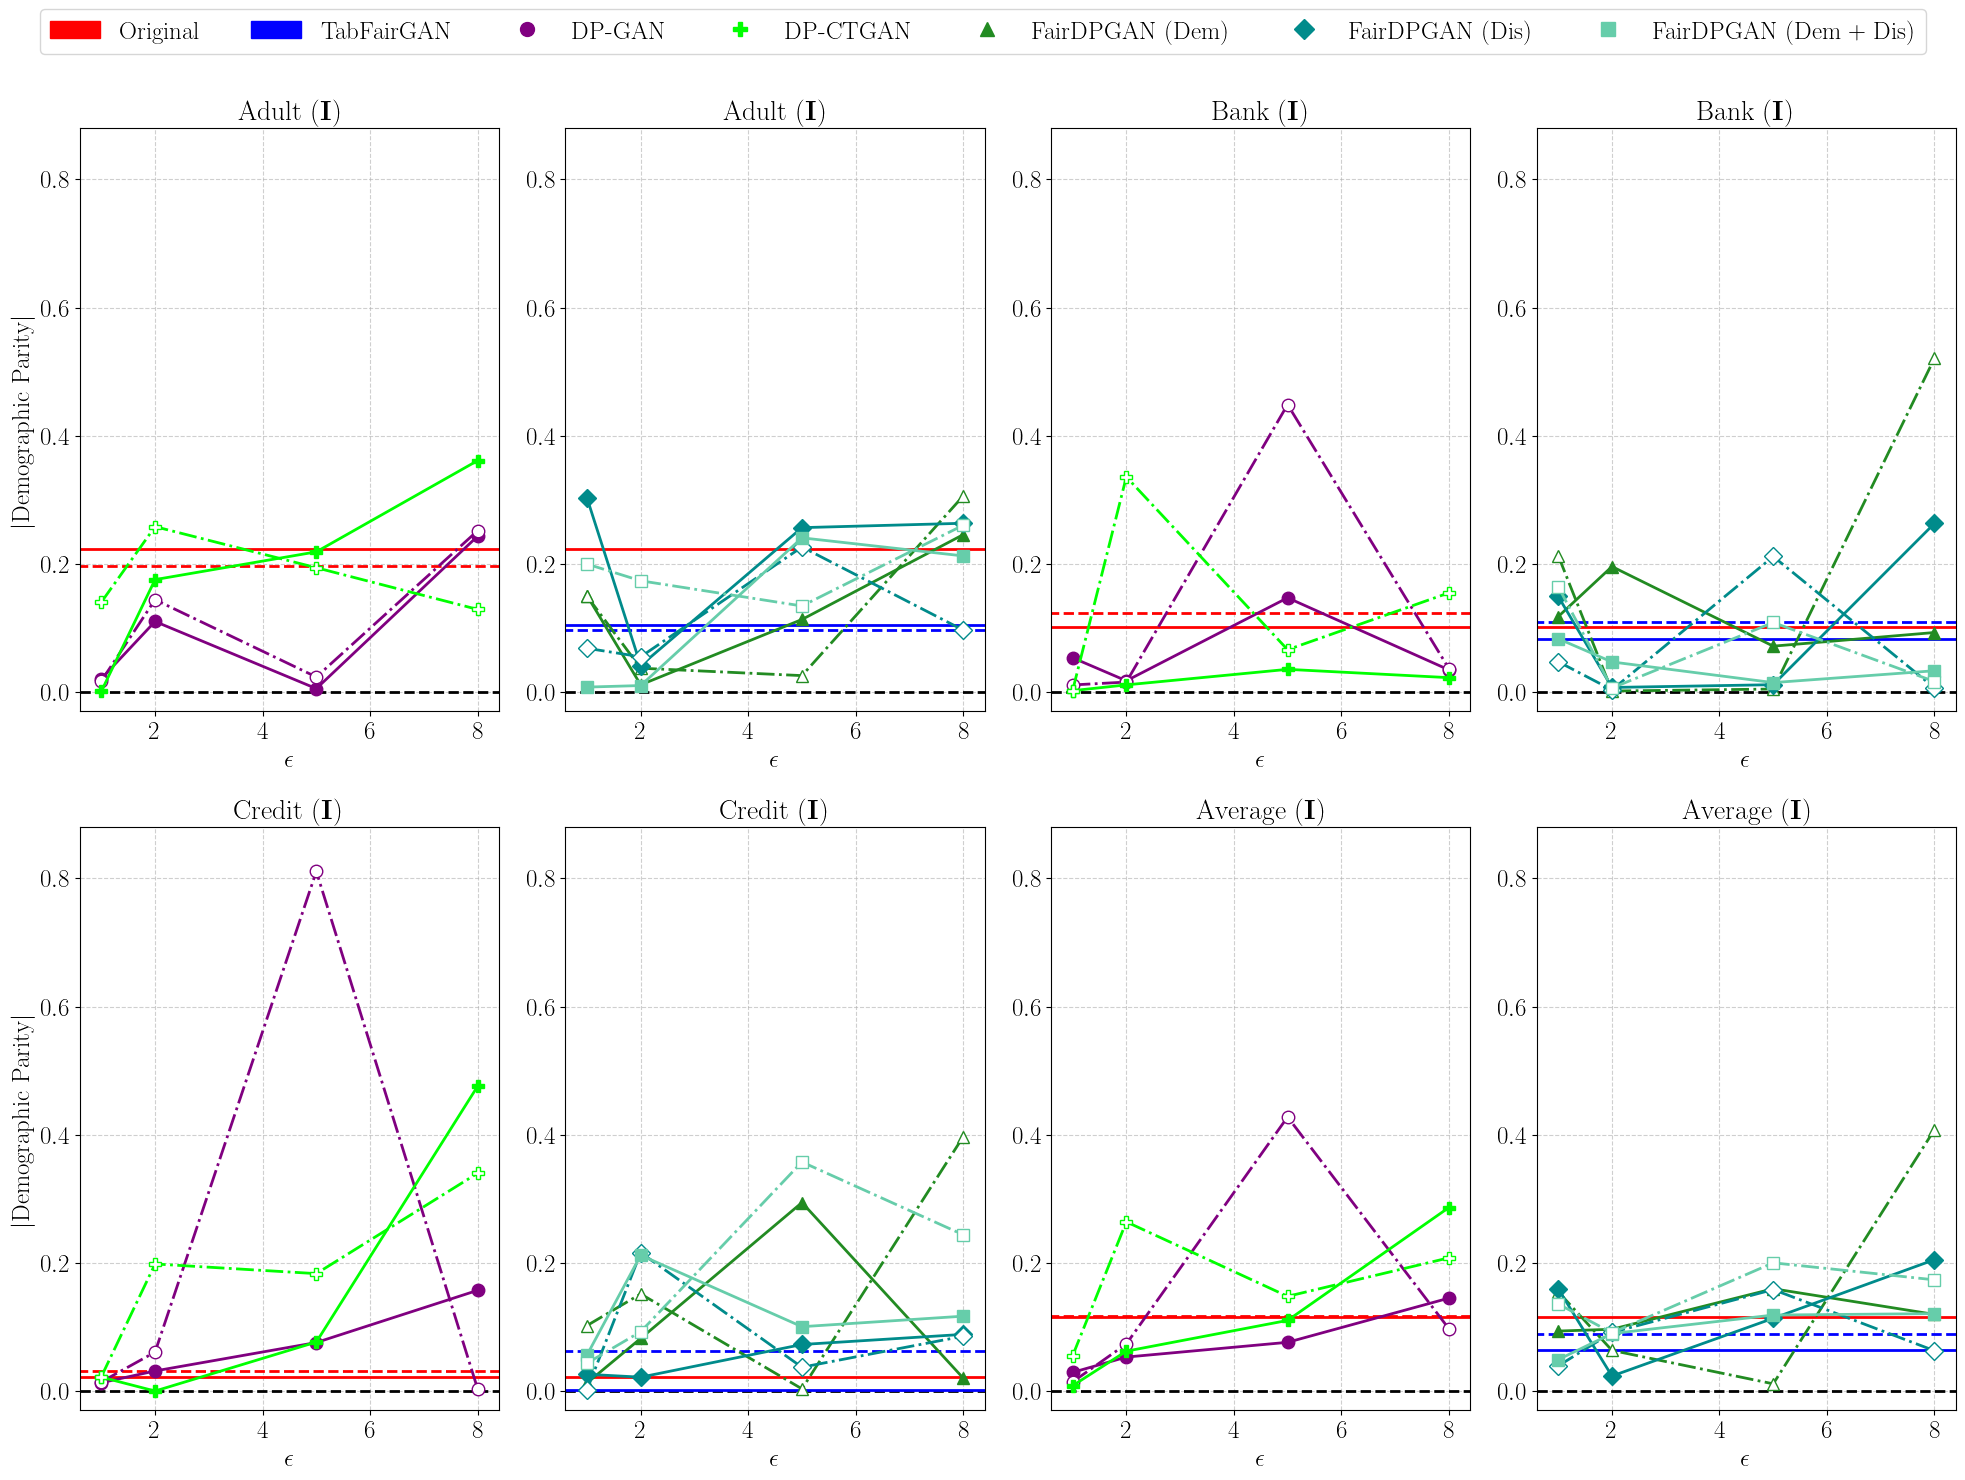

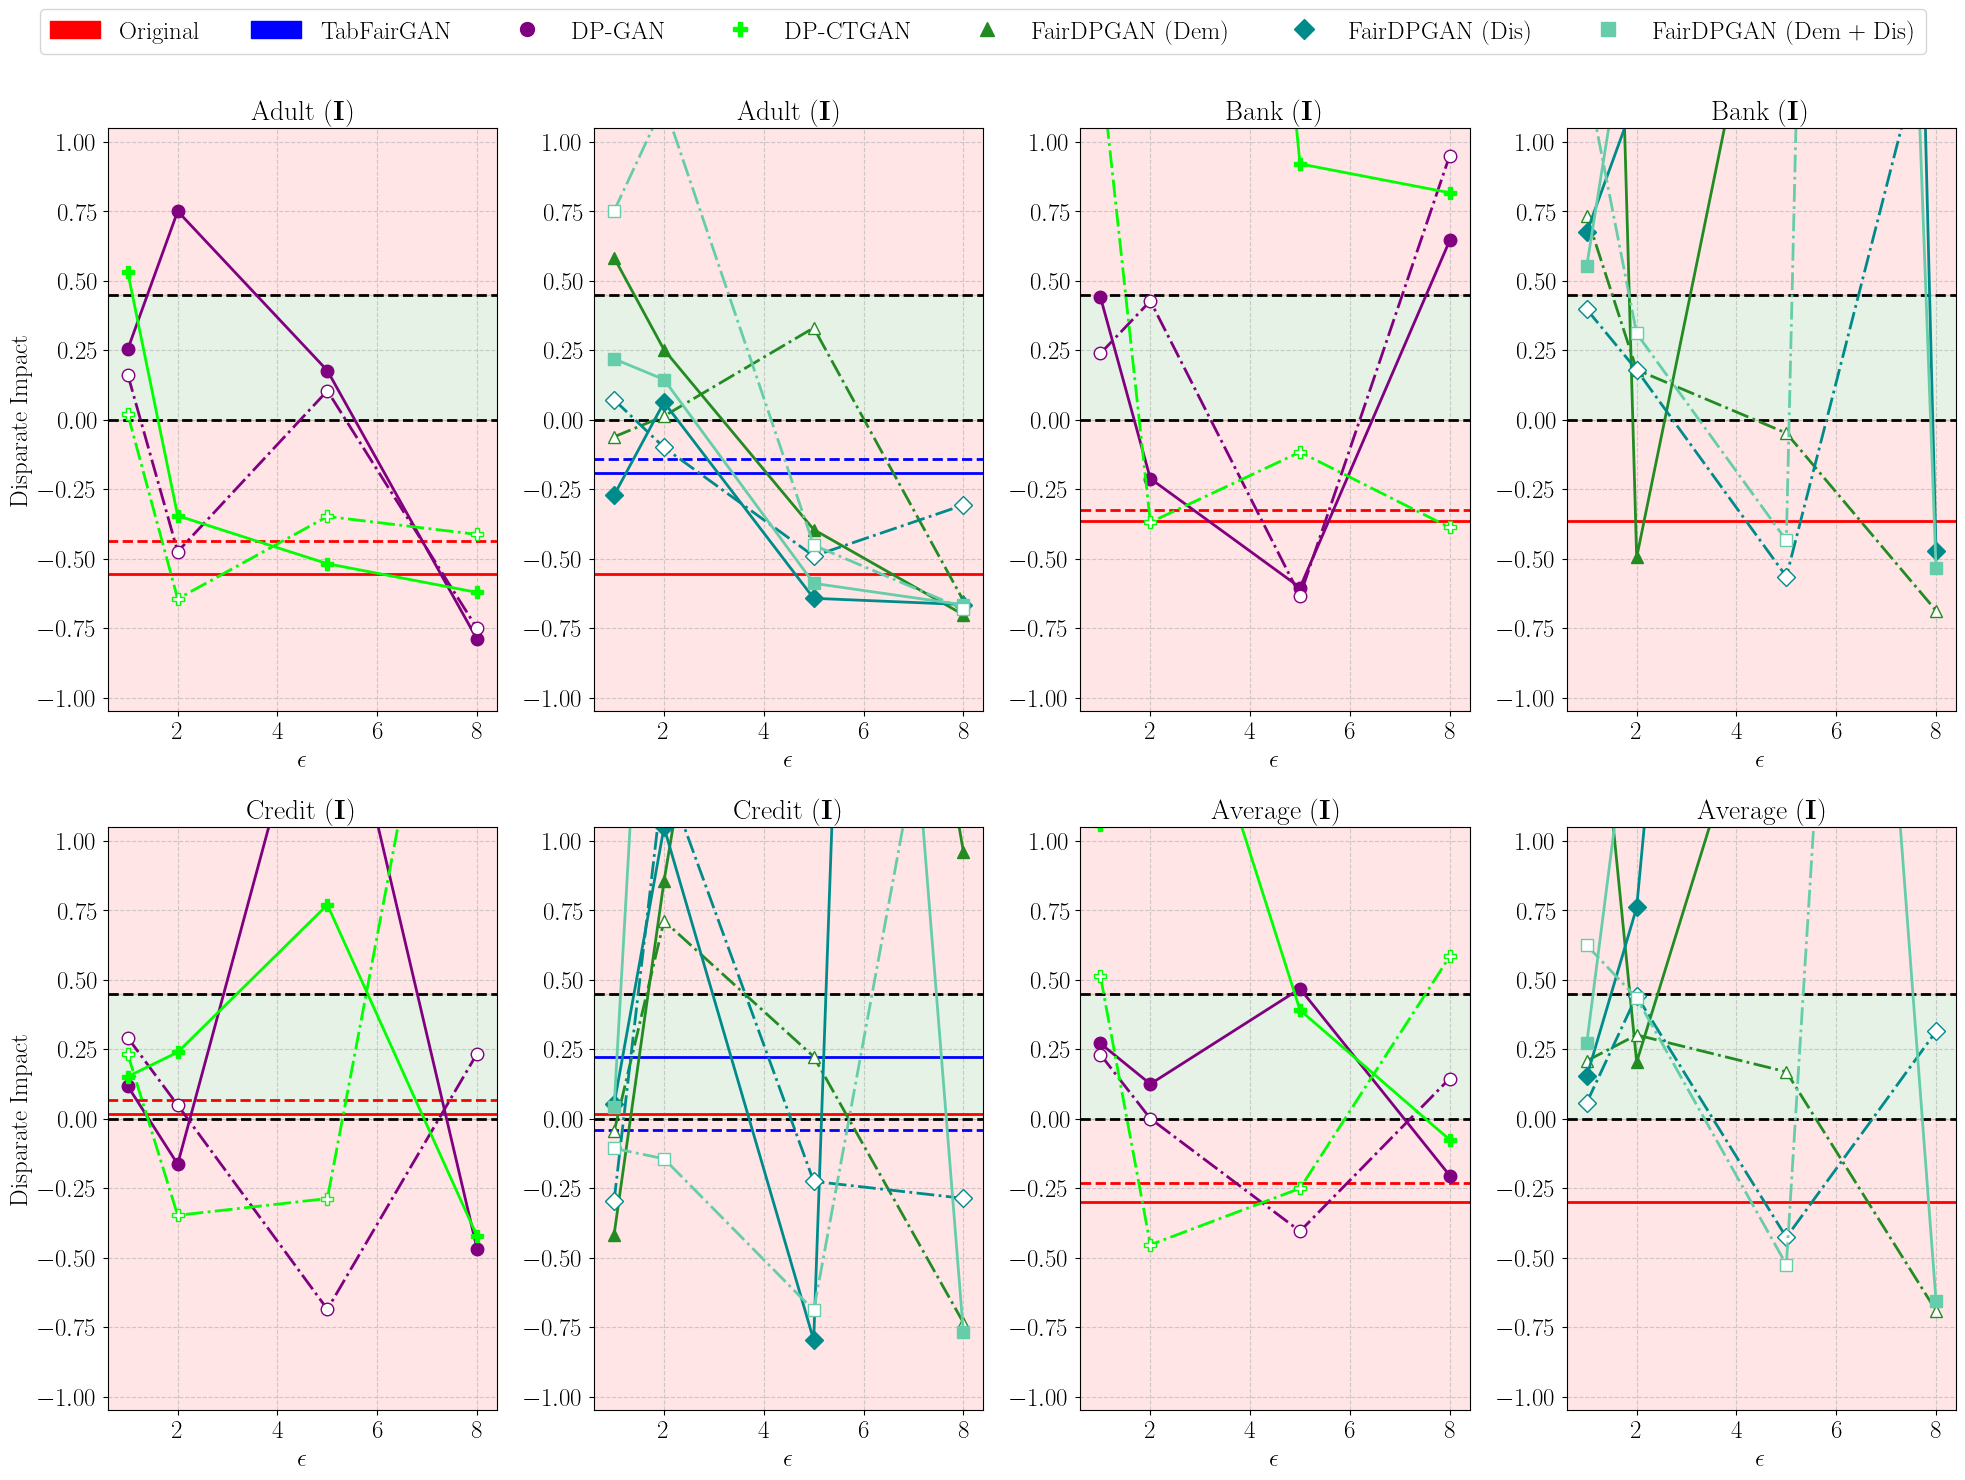

In [71]:
# Plotting dataset fairness metrics of the 'best' synthetic datasets from all our models.
labels = ["Original", "TabFairGAN", "DP-GAN", "DP-CTGAN", "FairDPGAN (Dem)", "FairDPGAN (Dis)", "FairDPGAN (Dem + Dis)"]
colors = ["red", "blue", "purple", "lime", "forestgreen", "darkcyan", "mediumaquamarine"]
limits = {"dem-parity": (-0.03, 0.88), "dis-impact": (-1.05, 1.05)}
fairness_clf = ["dem-parity", "dis-impact"]
fairness_labels = ["Demographic Parity", "Disparate Impact"]
markers = ["o", "P", "^", "D", "s"]
msize = 9

for f in fairness_clf:
    # Create a figure for the aggregated plot.
    fig, axes = plt.subplots(2, 4, figsize = (20, 15.0))  # 2 x 4 grid
    for c in range(0, 8):
        if c == 0 or c == 1:
            r = 0
            dataset = "Adult"
            results_np = pd.concat([adult_results[f]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF = pd.concat([adult_tabfair_results[f]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP = pd.concat([adult_results_DP[f], adult_results_DP_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results = pd.concat([results_np, results_DP], axis = 1)

            results_DPC = pd.concat([adult_results_DPC[f], adult_results_DPC_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT = pd.concat([results_TF, results_DPC], axis = 1)

            results_fdemDP = pd.concat([adult_results_dem[f], adult_results_dem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

            results_fdisDP = pd.concat([adult_results_dis[f], adult_results_dis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

            results_fdemdiDP = pd.concat([adult_results_demdi[f], adult_results_demdi_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

            # Results without preprocessing.
            results_np_old = pd.concat([adult_nop_results[f]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF_old = pd.concat([adult_tabfair_old[f]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP_old = pd.concat([adult_DP_old[f], adult_DP_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_old = pd.concat([results_np_old, results_DP_old], axis = 1)

            results_DPC_old = pd.concat([adult_DPC_old[f], adult_DPC_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT_old = pd.concat([results_TF_old, results_DPC_old], axis = 1)

            results_fdemDP_old = pd.concat([adult_dem_old[f], adult_dem_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem_old = pd.concat([results_np_old, results_fdemDP_old], axis = 1)

            results_fdisDP_old = pd.concat([adult_dis_old[f], adult_dis_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis_old = pd.concat([results_np_old, results_fdisDP_old], axis = 1)

            results_fdemdiDP_old = pd.concat([adult_demdi_old[f], adult_demdi_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi_old = pd.concat([results_np_old, results_fdemdiDP_old], axis = 1)

        elif c == 2 or c == 3:
            r = 0
            dataset = "Bank"
            results_np = pd.concat([bank_results[f]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF = pd.concat([bank_tabfair_results[f]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP = pd.concat([bank_results_DP[f], bank_results_DP_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results = pd.concat([results_np, results_DP], axis = 1)

            results_DPC = pd.concat([bank_results_DPC[f], bank_results_DPC_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT = pd.concat([results_TF, results_DPC], axis = 1)

            results_fdemDP = pd.concat([bank_results_dem[f], bank_results_dem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

            results_fdisDP = pd.concat([bank_results_dis[f], bank_results_dis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

            results_fdemdiDP = pd.concat([bank_results_demdi[f], bank_results_demdi_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

            # Results without preprocessing.
            results_np_old = pd.concat([bank_nop_results[f]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF_old = pd.concat([bank_tabfair_old[f]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP_old = pd.concat([bank_DP_old[f], bank_DP_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_old = pd.concat([results_np_old, results_DP_old], axis = 1)

            results_DPC_old = pd.concat([bank_DPC_old[f], bank_DPC_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT_old = pd.concat([results_TF_old, results_DPC_old], axis = 1)

            results_fdemDP_old = pd.concat([bank_dem_old[f], bank_dem_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem_old = pd.concat([results_np_old, results_fdemDP_old], axis = 1)

            results_fdisDP_old = pd.concat([bank_dis_old[f], bank_dis_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis_old = pd.concat([results_np_old, results_fdisDP_old], axis = 1)

            results_fdemdiDP_old = pd.concat([bank_demdi_old[f], bank_demdi_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi_old = pd.concat([results_np_old, results_fdemdiDP_old], axis = 1)

        elif c == 4 or c == 5:
            r = 1
            dataset = "Credit"
            results_np = pd.concat([credit_results[f]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF = pd.concat([credit_tabfair_results[f]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP = pd.concat([credit_results_DP[f], credit_results_DP_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results = pd.concat([results_np, results_DP], axis = 1)

            results_DPC = pd.concat([credit_results_DPC[f], credit_results_DPC_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT = pd.concat([results_TF, results_DPC], axis = 1)

            results_fdemDP = pd.concat([credit_results_dem[f], credit_results_dem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

            results_fdisDP = pd.concat([credit_results_dis[f], credit_results_dis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

            results_fdemdiDP = pd.concat([credit_results_demdi[f], credit_results_demdi_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

            # Results without preprocessing.
            results_np_old = pd.concat([credit_nop_results[f]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF_old = pd.concat([credit_tabfair_old[f]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP_old = pd.concat([credit_DP_old[f], credit_DP_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_old = pd.concat([results_np_old, results_DP_old], axis = 1)

            results_DPC_old = pd.concat([credit_DPC_old[f], credit_DPC_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT_old = pd.concat([results_TF_old, results_DPC_old], axis = 1)

            results_fdemDP_old = pd.concat([credit_dem_old[f], credit_dem_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem_old = pd.concat([results_np_old, results_fdemDP_old], axis = 1)

            results_fdisDP_old = pd.concat([credit_dis_old[f], credit_dis_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis_old = pd.concat([results_np_old, results_fdisDP_old], axis = 1)

            results_fdemdiDP_old = pd.concat([credit_demdi_old[f], credit_demdi_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi_old = pd.concat([results_np_old, results_fdemdiDP_old], axis = 1)
                
        else:
            r = 1
            dataset = "Average"
            if f == "dem-parity":
                results = pd.DataFrame({"mean": [np.mean(avg_dem_real)] + list(np.mean(avg_dem_DP, axis = 1)),
                                        "std": [np.std(avg_dem_real)] + list(np.std(avg_dem_DP, axis = 1))},
                                       index = ["Real", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                results_CT = pd.DataFrame({"mean": [np.mean(avg_dem_TF)] + list(np.mean(avg_dem_CT, axis = 1)), 
                                           "std": [np.std(avg_dem_TF)] + list(np.std(avg_dem_CT, axis = 1))},
                                          index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T

                results_fdem = pd.DataFrame({"mean": [np.mean(avg_dem_TF)] + list(np.mean(avg_dem_fdem, axis = 1)), 
                                             "std": [np.std(avg_dem_TF)] + list(np.std(avg_dem_fdem, axis = 1))},
                                            index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                results_fdis = pd.DataFrame({"mean": [np.mean(avg_dem_TF)] + list(np.mean(avg_dem_fdis, axis = 1)), 
                                             "std": [np.std(avg_dem_TF)] + list(np.std(avg_dem_fdis, axis = 1))},
                                            index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                results_fdemdi = pd.DataFrame({"mean": [np.mean(avg_dem_TF)] + list(np.mean(avg_dem_fdemdi, axis = 1)), 
                                               "std": [np.std(avg_dem_TF)] + list(np.std(avg_dem_fdemdi, axis = 1))},
                                              index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T

                # Results without preprocessing.
                results_old = DP_dem_old
                results_CT_old = CT_dem_old

                results_fdem_old = fdem_dem_old
                results_fdis_old = fdis_dem_old
                results_fdemdi_old = fdemdi_dem_old
            else:
                results = pd.DataFrame({"mean": [np.mean(avg_dis_real)] + list(np.mean(avg_dis_DP, axis = 1)),
                                        "std": [np.std(avg_dis_real)] + list(np.std(avg_dis_DP, axis = 1))},
                                       index = ["Real", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                results_CT = pd.DataFrame({"mean": [np.mean(avg_dis_TF)] + list(np.mean(avg_dis_CT, axis = 1)), 
                                           "std": [np.std(avg_dis_TF)] + list(np.std(avg_dis_CT, axis = 1))},
                                          index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T

                results_fdem = pd.DataFrame({"mean": [np.mean(avg_dis_TF)] + list(np.mean(avg_dis_fdem, axis = 1)), 
                                             "std": [np.std(avg_dis_TF)] + list(np.std(avg_dis_fdem, axis = 1))},
                                            index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                results_fdis = pd.DataFrame({"mean": [np.mean(avg_dis_TF)] + list(np.mean(avg_dis_fdis, axis = 1)), 
                                             "std": [np.std(avg_dis_TF)] + list(np.std(avg_dis_fdis, axis = 1))},
                                            index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T
                results_fdemdi = pd.DataFrame({"mean": [np.mean(avg_dis_TF)] + list(np.mean(avg_dis_fdemdi, axis = 1)), 
                                               "std": [np.std(avg_dis_TF)] + list(np.std(avg_dis_fdemdi, axis = 1))},
                                              index = ["TF", "epsi_1", "epsi_2", "epsi_5", "epsi_8"]).T

                # Results without preprocessing.
                results_old = DP_dis_old
                results_CT_old = CT_dis_old

                results_fdem_old = fdem_dis_old
                results_fdis_old = fdis_dis_old
                results_fdemdi_old = fdemdi_dis_old

        results_all = [results, results_CT, results_fdem, results_fdis, results_fdemdi]
        results_all_old = [results_old, results_CT_old, results_fdem_old, results_fdis_old, results_fdemdi_old]
        
        # Customizing the plot.
        col = fairness_clf.index(f)
        if r == 0:
            ax = axes[r, c] 
        if r == 1:
            ax = axes[r, c - 4]
        ax.set_title(f"{dataset} " + r"($\bf{I}$)")
        ax.set_xlabel("$\epsilon$")
        if c == 0 or c == 4:
            if f == "dis-impact":
                ax.set_ylabel(fairness_labels[col])
            else:
                ax.set_ylabel(f"$|${fairness_labels[col]}$|$")
        ax.set_aspect('auto')
        ax.set_xlim([0.6, 8.4])
        ax.set_ylim(limits[f][0], limits[f][1])
        ax.grid(True, linestyle = '--', alpha = 0.6)
    
        # Plotting a dashed line for the demographic parity and disparate impact parameters.
        ax.axhline(0, 0, 5, ls = "--", c = "black")

        if f == "dis-impact":
            # Plotting another dashed line for the disparate impact parameter.
            ax.axhline(0.45, 0, 5, ls = "--", c = "black")
            # Plotting three rectangular patches for the disparate impact parameter.
            rect1 = mpatches.Rectangle(xy = (-0.5, 0), width = 11.5, height = 0.45, color='green', alpha = 0.1, ec='green')
            ax.add_patch(rect1)
            rect2 = mpatches.Rectangle(xy = (-0.5, 0), width = 11.5, height = -10.5, color='red', alpha = 0.1, ec='red')
            ax.add_patch(rect2)
            rect3 = mpatches.Rectangle(xy = (-0.5, 0.45), width = 11.5, height = 10.5, color='red', alpha = 0.1, ec='red')
            ax.add_patch(rect3)

        # Create lineplots for the current metric: Adult, Bank, Credit & Average.
        if c != 6 and c != 7:
            for res in range(len(results_all)):
                if res == 0:
                    ax.plot([0, 11], [results_all[res].iloc[0][0]]*len([0, 11]), color = colors[res])   # original
                    if c % 2 == 0:
                        ax.plot([0, 11], [results_all_old[res].iloc[0][0]]*len([0, 11]), color = colors[res], ls = "--")   # original (old)
                        ax.plot(epsi, results_all[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize)   # DP-GAN
                        ax.plot(epsi, results_all_old[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                                ls = "-.", markerfacecolor = "white",)   # DP-GAN (old)
                elif res == 1:
                    if c % 2 != 0:
                        ax.plot([0, 11], [results_all[res].iloc[0][0]]*len([0, 11]), color = colors[res])   # TabFairGAN
                        ax.plot([0, 11], [results_all_old[res].iloc[0][0]]*len([0, 11]), color = colors[res], ls = "--")   # TabFairGAN (old)
                    if c % 2 == 0:
                        ax.plot(epsi, results_all[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize)   # DP-CTGAN
                        ax.plot(epsi, results_all_old[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                                ls = "-.", markerfacecolor = "white",)   # DP-CTGAN (old)
                else:
                    if c % 2 != 0:
                        ax.plot(epsi, results_all[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                                )   # Fair DP-GANs
                        ax.plot(epsi, results_all_old[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                                ls = "-.", markerfacecolor = "white",)   # Fair DP-GANs (old)
        else:
            for res in range(len(results_all)):
                if res == 0:
                    ax.plot([0, 11], [results_all[res].iloc[0][0]]*len([0, 11]), color = colors[res],
                               )   # original
                    if c % 2 == 0:
                        ax.plot([0, 11], [results_all_old[res].iloc[0][0]]*len([0, 11]), color = colors[res], ls = "--", 
                                   )   # original (old)
                        ax.plot(epsi, results_all[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize, 
                                   )   # DP-GAN
                        ax.plot(epsi, results_all_old[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                                    ls = "-.", markerfacecolor = "white",
                                   )   # DP-GAN (old)
                elif res == 1:
                    if c % 2 != 0:
                        ax.plot([0, 11], [results_all[res].iloc[0][0]]*len([0, 11]), color = colors[res],
                                   )   # TabFairGAN
                        ax.plot([0, 11], [results_all_old[res].iloc[0][0]]*len([0, 11]), color = colors[res], ls = "--",
                                   )   # TabFairGAN (old)
                    if c % 2 == 0:
                        ax.plot(epsi, results_all[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize, 
                                   )   # DP-CTGAN
                        ax.plot(epsi, results_all_old[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                                    ls = "-.", markerfacecolor = "white",
                                   )   # DP-CTGAN (old)
                else:
                    if c % 2 != 0:
                        ax.plot(epsi, results_all[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                                   )   # Fair DP-GANs
                        ax.plot(epsi, results_all_old[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                                    ls = "-.", markerfacecolor = "white",
                                   )   # Fair DP-GANs (old)

        if c == 0:
            h_patch = [mpatches.Patch(color = colors[i], label = labels[i]) for i in range(2)]
            h_lines = [mlines.Line2D([], [], color = colors[i], marker = markers[i - 2], label = labels[i], linestyle = 'None',
                        markersize = 10) for i in range(2, len(colors))]
            plt.figlegend(handles = h_patch + h_lines, ncol = 7, loc = "upper center", bbox_to_anchor = (0.5, 1.0))
        
        plt.tight_layout(rect = [0, 0, 1, 0.95])
    plt.show()

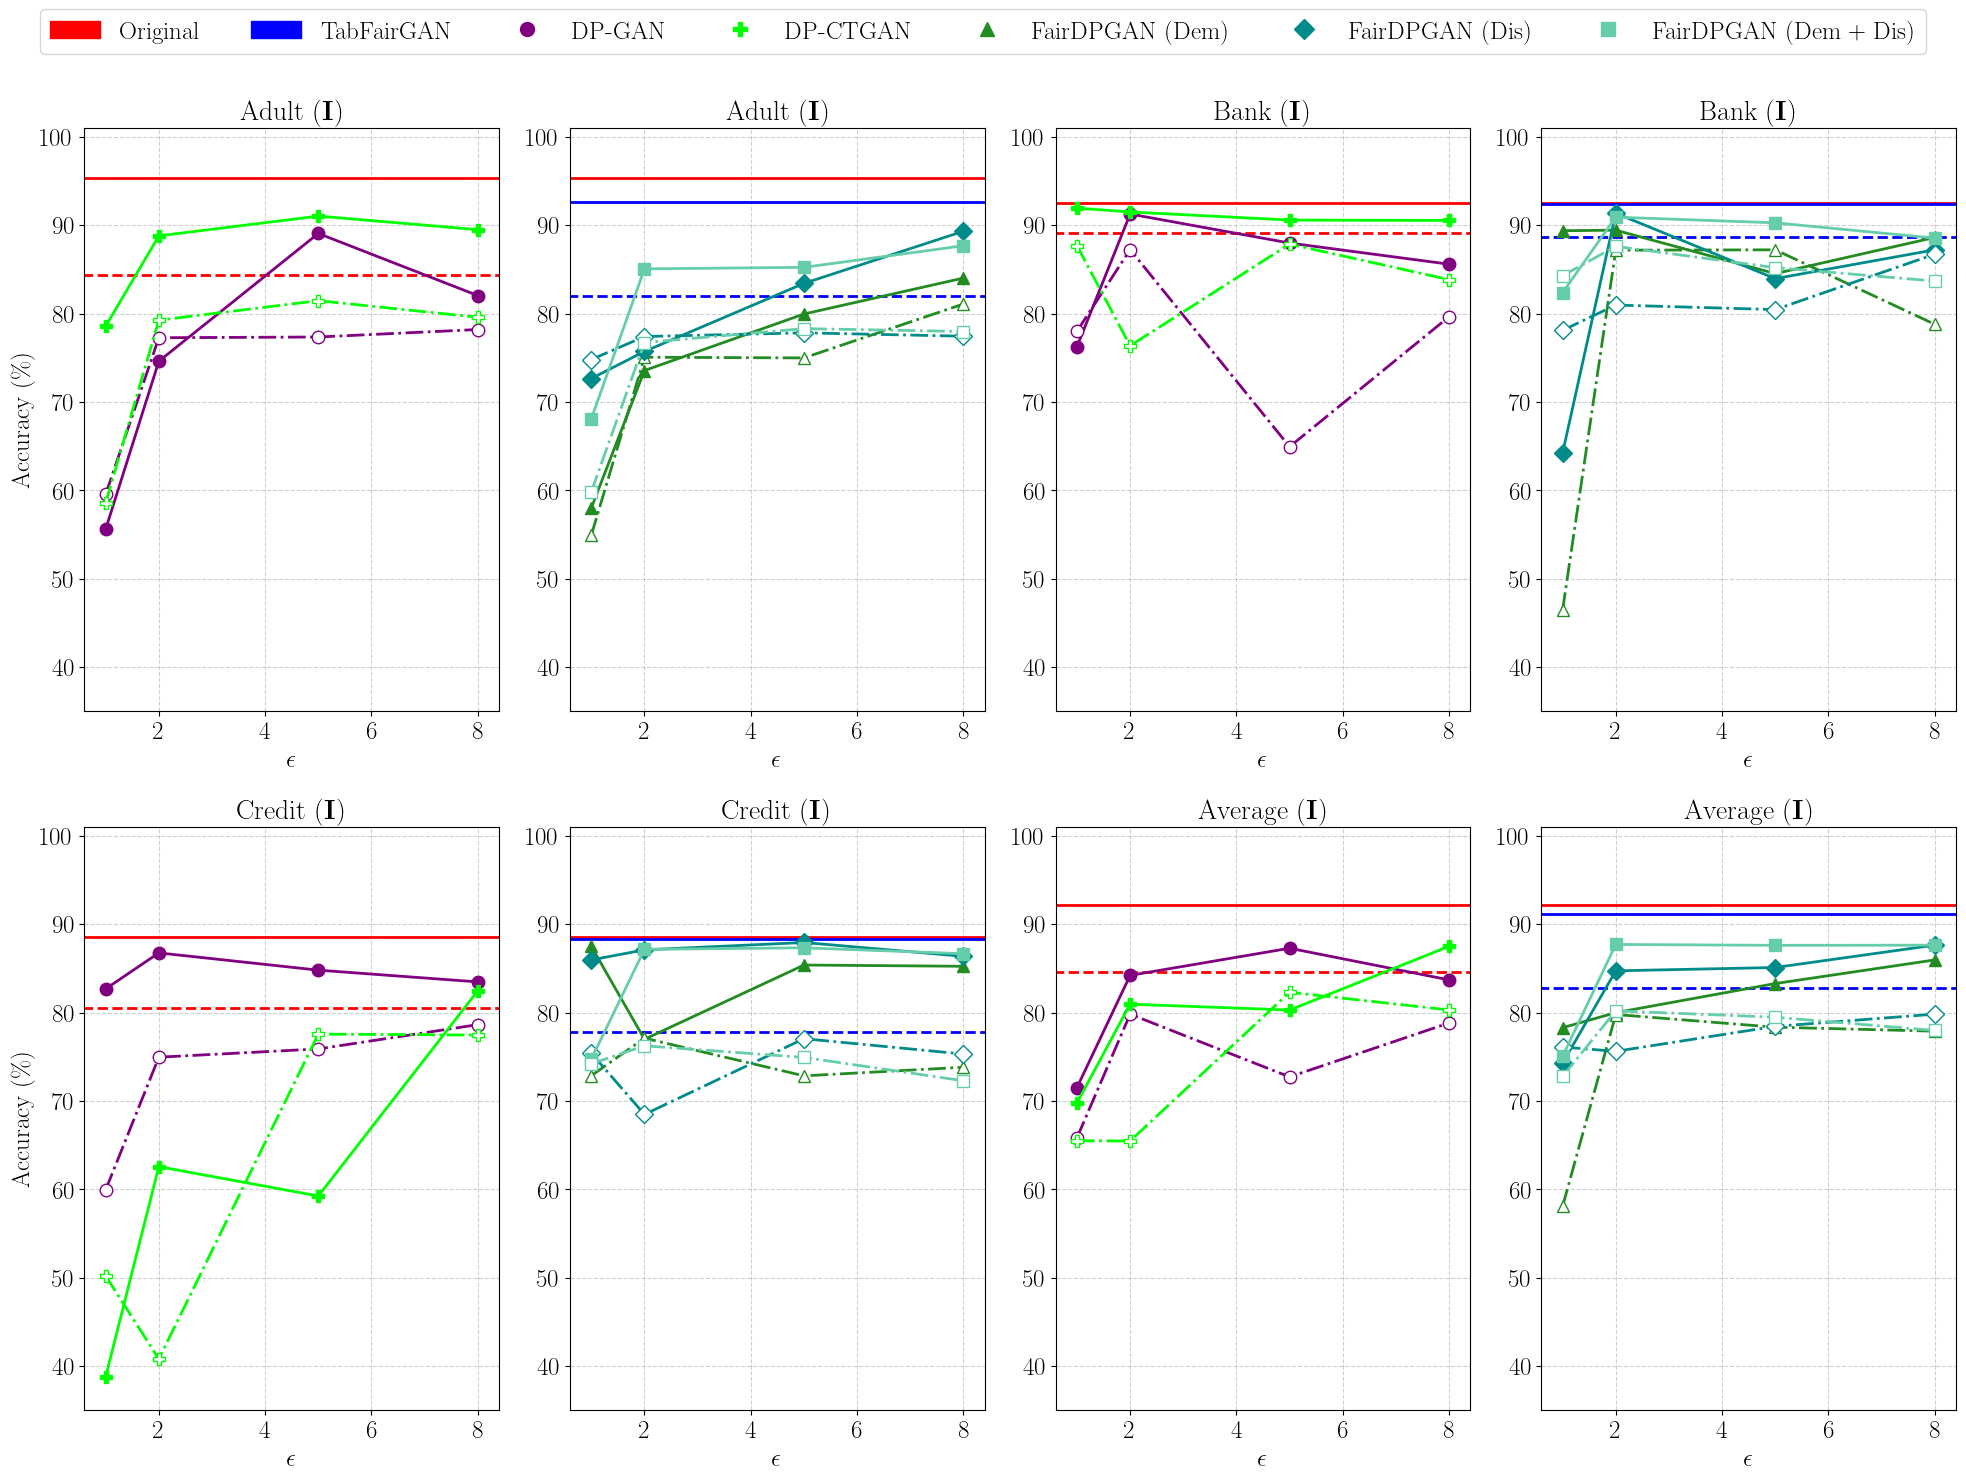

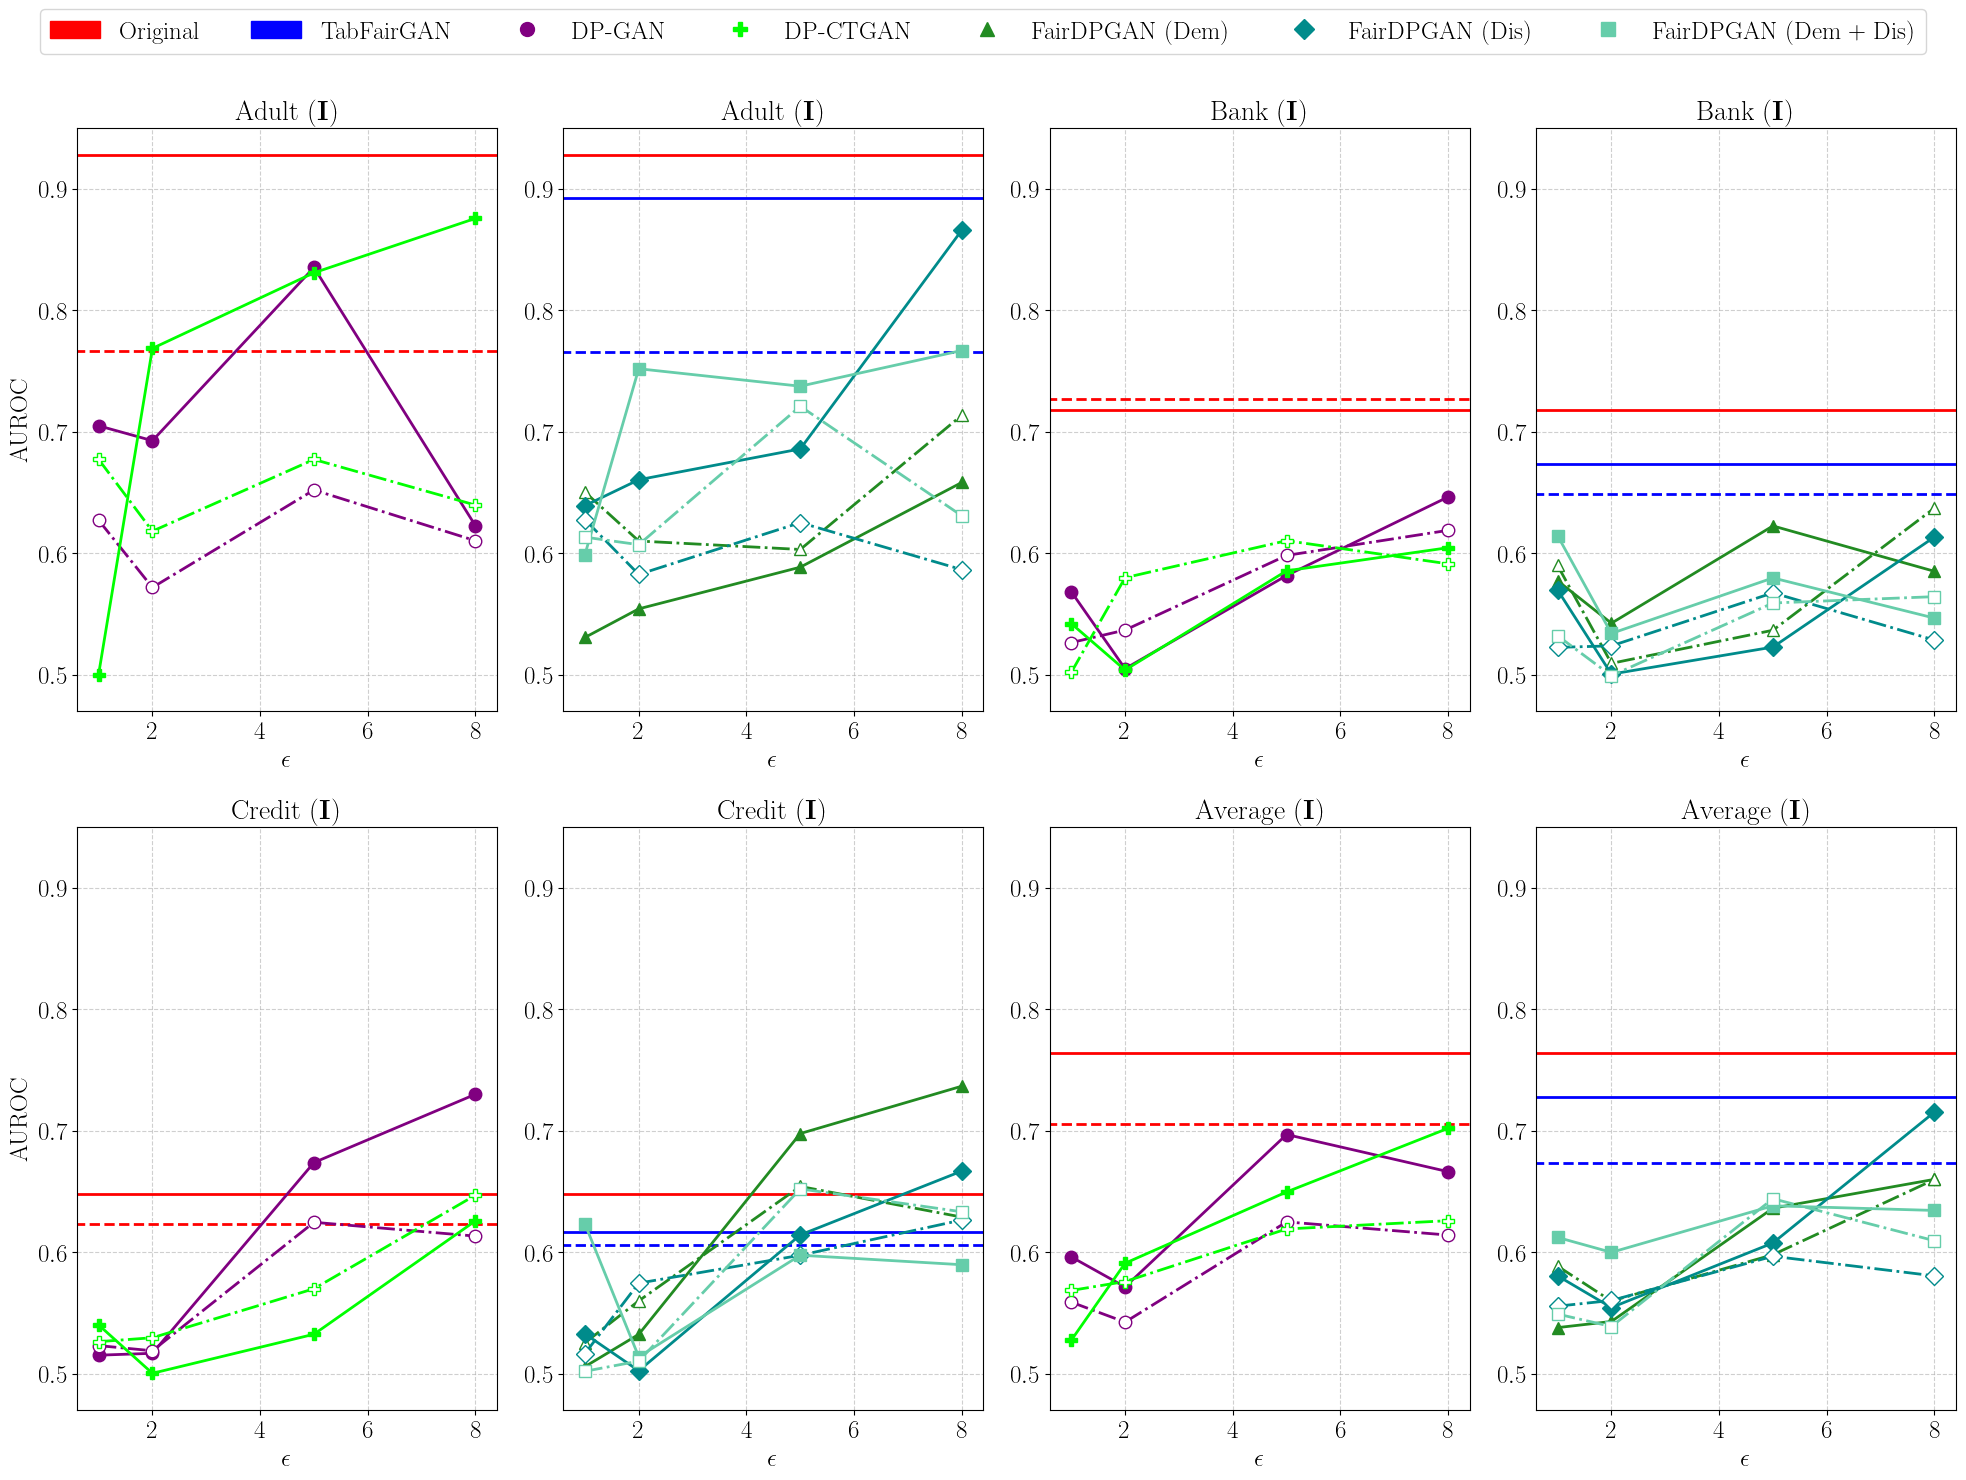

In [72]:
# Plotting utility metrics of classifiers trained on the 'best' synthetic datasets from all our models.
labels = ["Original", "TabFairGAN", "DP-GAN", "DP-CTGAN", "FairDPGAN (Dem)", "FairDPGAN (Dis)", "FairDPGAN (Dem + Dis)"]
colors = ["red", "blue", "purple", "lime", "forestgreen", "darkcyan", "mediumaquamarine"]
limits = {"acc": (35, 101), "auroc": (0.47, 0.95)}
utility_clf = ["acc", "auroc"]
utility_labels = ["Accuracy (\%)", "AUROC"]
markers = ["o", "P", "^", "D", "s"]
msize = 9

for u in utility_clf:
    # Create a figure for the aggregated plot.
    fig, axes = plt.subplots(2, 4, figsize = (20, 15.0))  # 2 x 4 grid
    for c in range(0, 8):
        if c == 0 or c == 1:
            r = 0
            dataset = "Adult"
            results_np = pd.concat([adult_results[u]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF = pd.concat([adult_tabfair_results[u]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP = pd.concat([adult_results_DP[u], adult_results_DP_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results = pd.concat([results_np, results_DP], axis = 1)

            results_DPC = pd.concat([adult_results_DPC[u], adult_results_DPC_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT = pd.concat([results_TF, results_DPC], axis = 1)

            results_fdemDP = pd.concat([adult_results_dem[u], adult_results_dem_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

            results_fdisDP = pd.concat([adult_results_dis[u], adult_results_dis_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

            results_fdemdiDP = pd.concat([adult_results_demdi[u], adult_results_demdi_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

            # Results without preprocessing.
            results_np_old = pd.concat([adult_nop_results[u]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF_old = pd.concat([adult_tabfair_old[u]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP_old = pd.concat([adult_DP_old[u], adult_DP_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_old = pd.concat([results_np_old, results_DP_old], axis = 1)

            results_DPC_old = pd.concat([adult_DPC_old[u], adult_DPC_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT_old = pd.concat([results_TF_old, results_DPC_old], axis = 1)

            results_fdemDP_old = pd.concat([adult_dem_old[u], adult_dem_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem_old = pd.concat([results_np_old, results_fdemDP_old], axis = 1)

            results_fdisDP_old = pd.concat([adult_dis_old[u], adult_dis_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis_old = pd.concat([results_np_old, results_fdisDP_old], axis = 1)

            results_fdemdiDP_old = pd.concat([adult_demdi_old[u], adult_demdi_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi_old = pd.concat([results_np_old, results_fdemdiDP_old], axis = 1)

        elif c == 2 or c == 3:
            r = 0
            dataset = "Bank"
            results_np = pd.concat([bank_results[u]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF = pd.concat([bank_tabfair_results[u]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP = pd.concat([bank_results_DP[u], bank_results_DP_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results = pd.concat([results_np, results_DP], axis = 1)

            results_DPC = pd.concat([bank_results_DPC[u], bank_results_DPC_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT = pd.concat([results_TF, results_DPC], axis = 1)

            results_fdemDP = pd.concat([bank_results_dem[u], bank_results_dem_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

            results_fdisDP = pd.concat([bank_results_dis[u], bank_results_dis_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

            results_fdemdiDP = pd.concat([bank_results_demdi[u], bank_results_demdi_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

            # Results without preprocessing.
            results_np_old = pd.concat([bank_nop_results[u]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF_old = pd.concat([bank_tabfair_old[u]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP_old = pd.concat([bank_DP_old[u], bank_DP_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_old = pd.concat([results_np_old, results_DP_old], axis = 1)

            results_DPC_old = pd.concat([bank_DPC_old[u], bank_DPC_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT_old = pd.concat([results_TF_old, results_DPC_old], axis = 1)

            results_fdemDP_old = pd.concat([bank_dem_old[u], bank_dem_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem_old = pd.concat([results_np_old, results_fdemDP_old], axis = 1)

            results_fdisDP_old = pd.concat([bank_dis_old[u], bank_dis_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis_old = pd.concat([results_np_old, results_fdisDP_old], axis = 1)

            results_fdemdiDP_old = pd.concat([bank_demdi_old[u], bank_demdi_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi_old = pd.concat([results_np_old, results_fdemdiDP_old], axis = 1)

        elif c == 4 or c == 5:
            r = 1
            dataset = "Credit"
            results_np = pd.concat([credit_results[u]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF = pd.concat([credit_tabfair_results[u]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP = pd.concat([credit_results_DP[u], credit_results_DP_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results = pd.concat([results_np, results_DP], axis = 1)

            results_DPC = pd.concat([credit_results_DPC[u], credit_results_DPC_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT = pd.concat([results_TF, results_DPC], axis = 1)

            results_fdemDP = pd.concat([credit_results_dem[u], credit_results_dem_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

            results_fdisDP = pd.concat([credit_results_dis[u], credit_results_dis_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

            results_fdemdiDP = pd.concat([credit_results_demdi[u], credit_results_demdi_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

            # Results without preprocessing.
            results_np_old = pd.concat([credit_nop_results[u]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF_old = pd.concat([credit_tabfair_old[u]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP_old = pd.concat([credit_DP_old[u], credit_DP_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_old = pd.concat([results_np_old, results_DP_old], axis = 1)

            results_DPC_old = pd.concat([credit_DPC_old[u], credit_DPC_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT_old = pd.concat([results_TF_old, results_DPC_old], axis = 1)

            results_fdemDP_old = pd.concat([credit_dem_old[u], credit_dem_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem_old = pd.concat([results_np_old, results_fdemDP_old], axis = 1)

            results_fdisDP_old = pd.concat([credit_dis_old[u], credit_dis_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis_old = pd.concat([results_np_old, results_fdisDP_old], axis = 1)

            results_fdemdiDP_old = pd.concat([credit_demdi_old[u], credit_demdi_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi_old = pd.concat([results_np_old, results_fdemdiDP_old], axis = 1)
                
        else:
            r = 1
            dataset = "Average"
            results_np = pd.concat([avg_real_results[u]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF = pd.concat([avg_TF_results[u]], axis = 1).set_axis(["TF"], axis = 1)

            results_DP = pd.concat([avg_DP_results[u], avg_DP_results_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results = pd.concat([results_np, results_DP], axis = 1)

            results_DPC = pd.concat([avg_CT_results[u], avg_CT_results_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT = pd.concat([results_TF, results_DPC], axis = 1)

            results_fdemDP = pd.concat([avg_fdem_results[u], avg_fdem_results_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

            results_fdisDP = pd.concat([avg_fdis_results[u], avg_fdis_results_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

            results_fdemdiDP = pd.concat([avg_fdemdi_results[u], avg_fdemdi_results_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

            # Results without preprocessing.
            results_np_old = pd.concat([avg_real_old[u]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF_old = pd.concat([avg_TF_old[u]], axis = 1).set_axis(["TF"], axis = 1)

            results_DP_old = pd.concat([avg_DP_old[u], avg_DP_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_old = pd.concat([results_np_old, results_DP_old], axis = 1)

            results_DPC_old = pd.concat([avg_CT_old[u], avg_CT_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT_old = pd.concat([results_TF_old, results_DPC_old], axis = 1)

            results_fdemDP_old = pd.concat([avg_fdem_old[u], avg_fdem_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem_old = pd.concat([results_np_old, results_fdemDP_old], axis = 1)

            results_fdisDP_old = pd.concat([avg_fdis_old[u], avg_fdis_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis_old = pd.concat([results_np_old, results_fdisDP_old], axis = 1)

            results_fdemdiDP_old = pd.concat([avg_fdemdi_old[u], avg_fdemdi_old_std[u]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi_old = pd.concat([results_np_old, results_fdemdiDP_old], axis = 1)

        results_all = [results, results_CT, results_fdem, results_fdis, results_fdemdi]
        results_all_old = [results_old, results_CT_old, results_fdem_old, results_fdis_old, results_fdemdi_old]
        
        # Customizing the plot.
        col = utility_clf.index(u)
        if r == 0:
            ax = axes[r, c] 
        if r == 1:
            ax = axes[r, c - 4]
        ax.set_title(f"{dataset} " + r"($\bf{I}$)")
        ax.set_xlabel("$\epsilon$")
        if c == 0 or c == 4:
            ax.set_ylabel(utility_labels[col])
        ax.set_aspect('auto')
        ax.set_xlim([0.6, 8.4])
        ax.set_ylim(limits[u][0], limits[u][1])
        ax.grid(True, linestyle = '--', alpha = 0.6)

        # Create lineplots for the current metric: Adult, Bank, Credit & Average.
        for res in range(len(results_all)):
            if res == 0:
                ax.plot([0, 11], [results_all[res].iloc[0][0]]*len([0, 11]), color = colors[res])   # original
                if c % 2 == 0:
                    ax.plot([0, 11], [results_all_old[res].iloc[0][0]]*len([0, 11]), color = colors[res], ls = "--")   # original (old)
                    ax.plot(epsi, results_all[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize)   # DP-GAN
                    ax.plot(epsi, results_all_old[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                            ls = "-.", markerfacecolor = "white",)   # DP-GAN (old)
            elif res == 1:
                if c % 2 != 0:
                    ax.plot([0, 11], [results_all[res].iloc[0][0]]*len([0, 11]), color = colors[res])   # TabFairGAN
                    ax.plot([0, 11], [results_all_old[res].iloc[0][0]]*len([0, 11]), color = colors[res], ls = "--")   # TabFairGAN (old)
                if c % 2 == 0:
                    ax.plot(epsi, results_all[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize)   # DP-CTGAN
                    ax.plot(epsi, results_all_old[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                            ls = "-.", markerfacecolor = "white",)   # DP-CTGAN (old)
            else:
                if c % 2 != 0:
                    ax.plot(epsi, results_all[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                            )   # Fair DP-GANs
                    ax.plot(epsi, results_all_old[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                            ls = "-.", markerfacecolor = "white",)   # Fair DP-GANs (old)

        if c == 0:
            h_patch = [mpatches.Patch(color = colors[i], label = labels[i]) for i in range(2)]
            h_lines = [mlines.Line2D([], [], color = colors[i], marker = markers[i - 2], label = labels[i], linestyle = 'None',
                        markersize = 10) for i in range(2, len(colors))]
            plt.figlegend(handles = h_patch + h_lines, ncol = 7, loc = "upper center", bbox_to_anchor = (0.5, 1.0))
        
        plt.tight_layout(rect = [0, 0, 1, 0.95])
    plt.show()

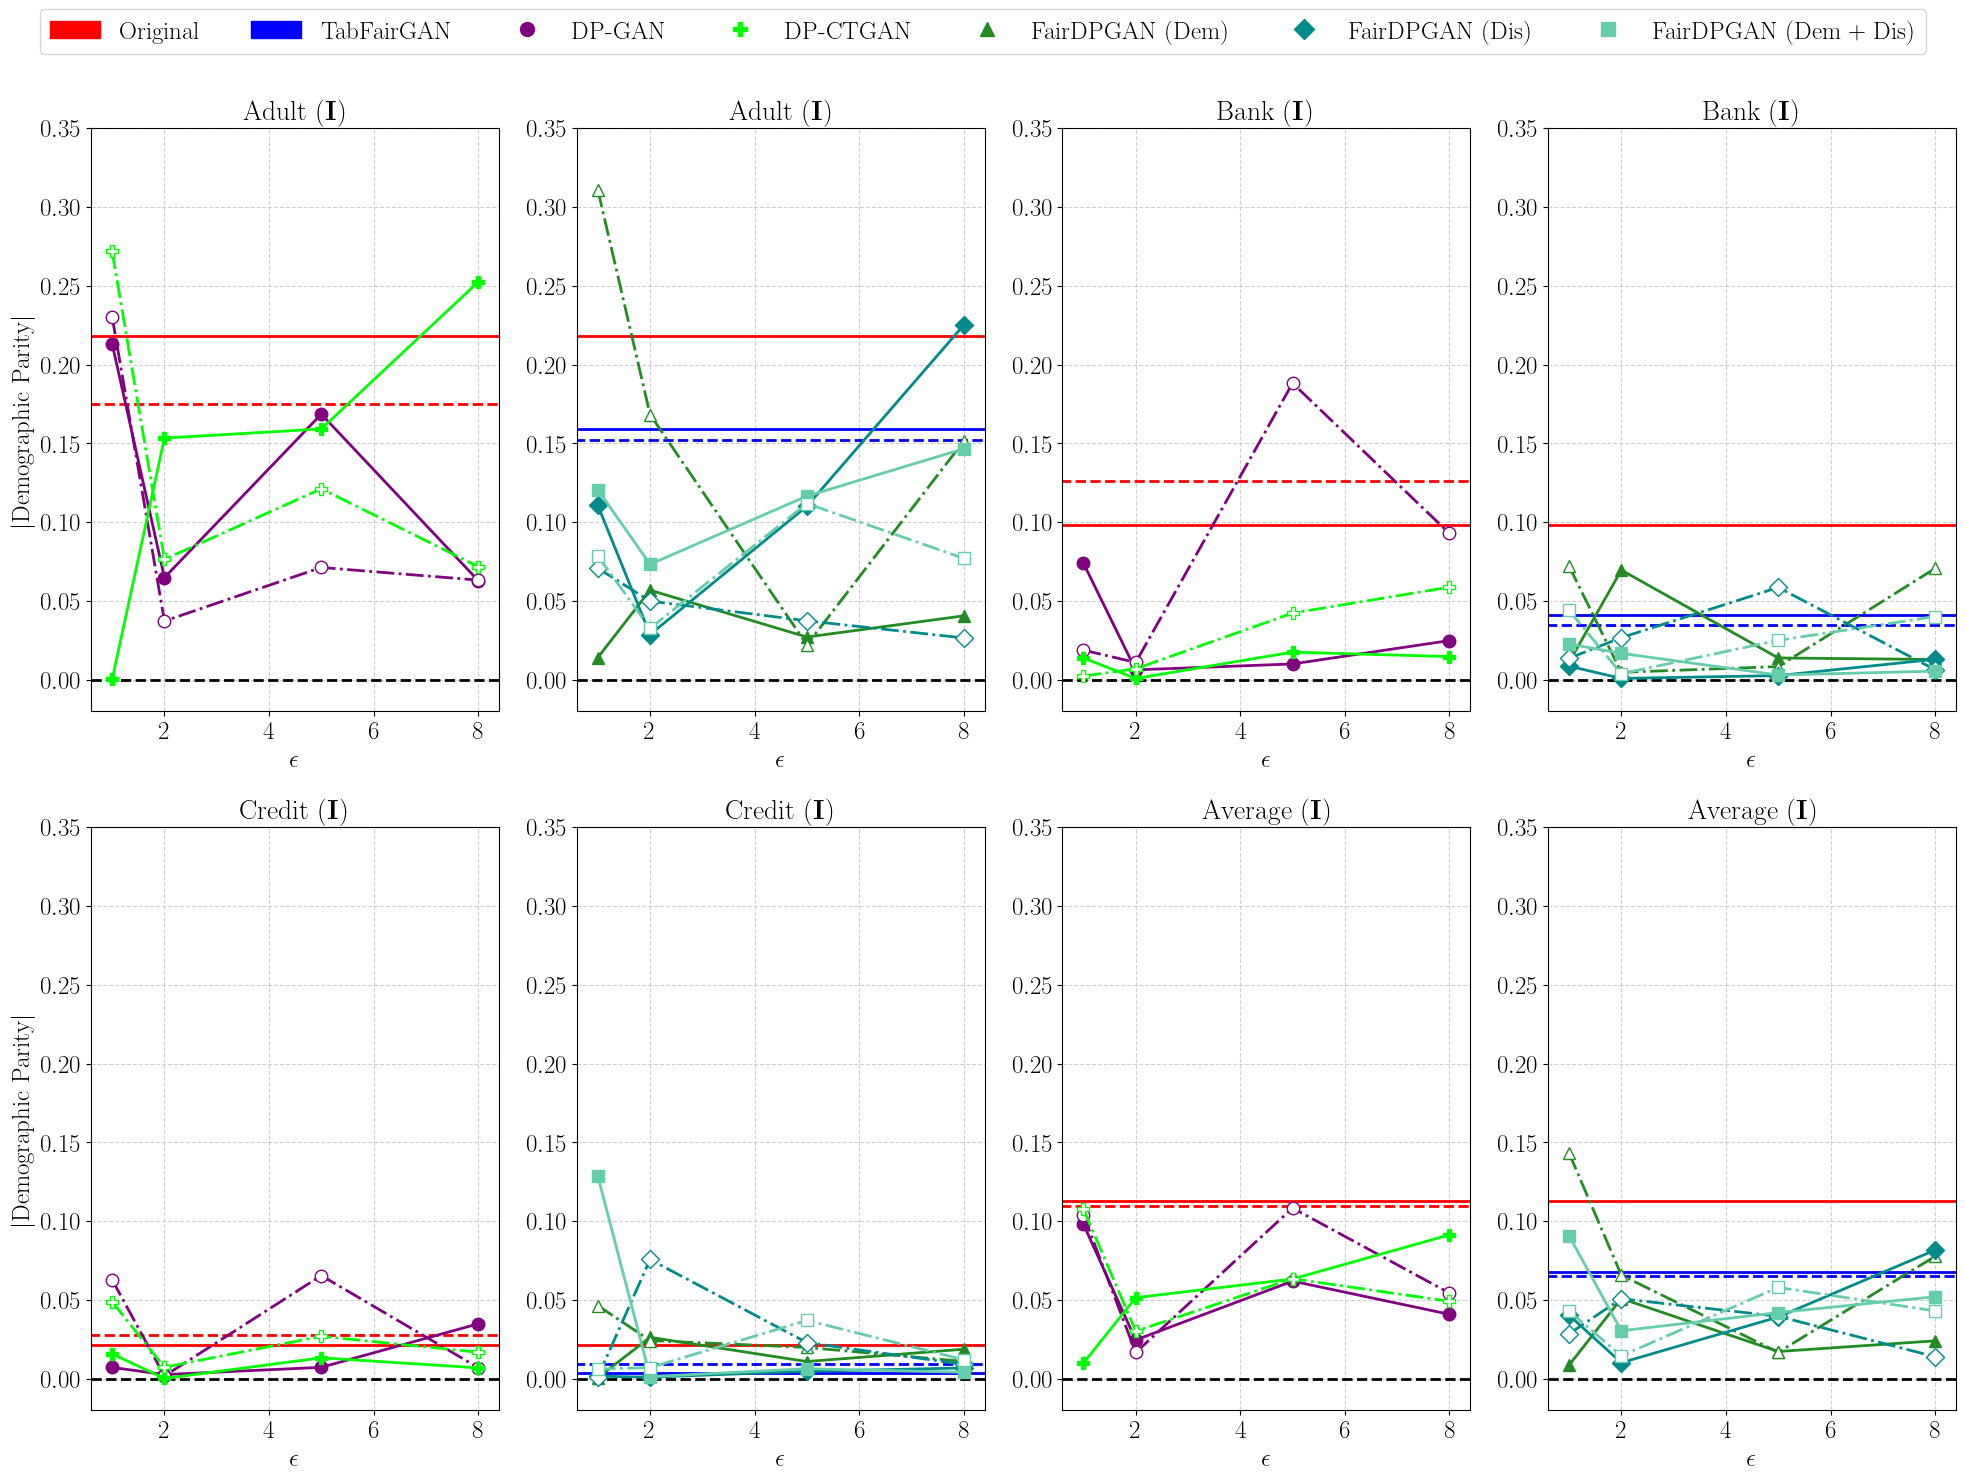

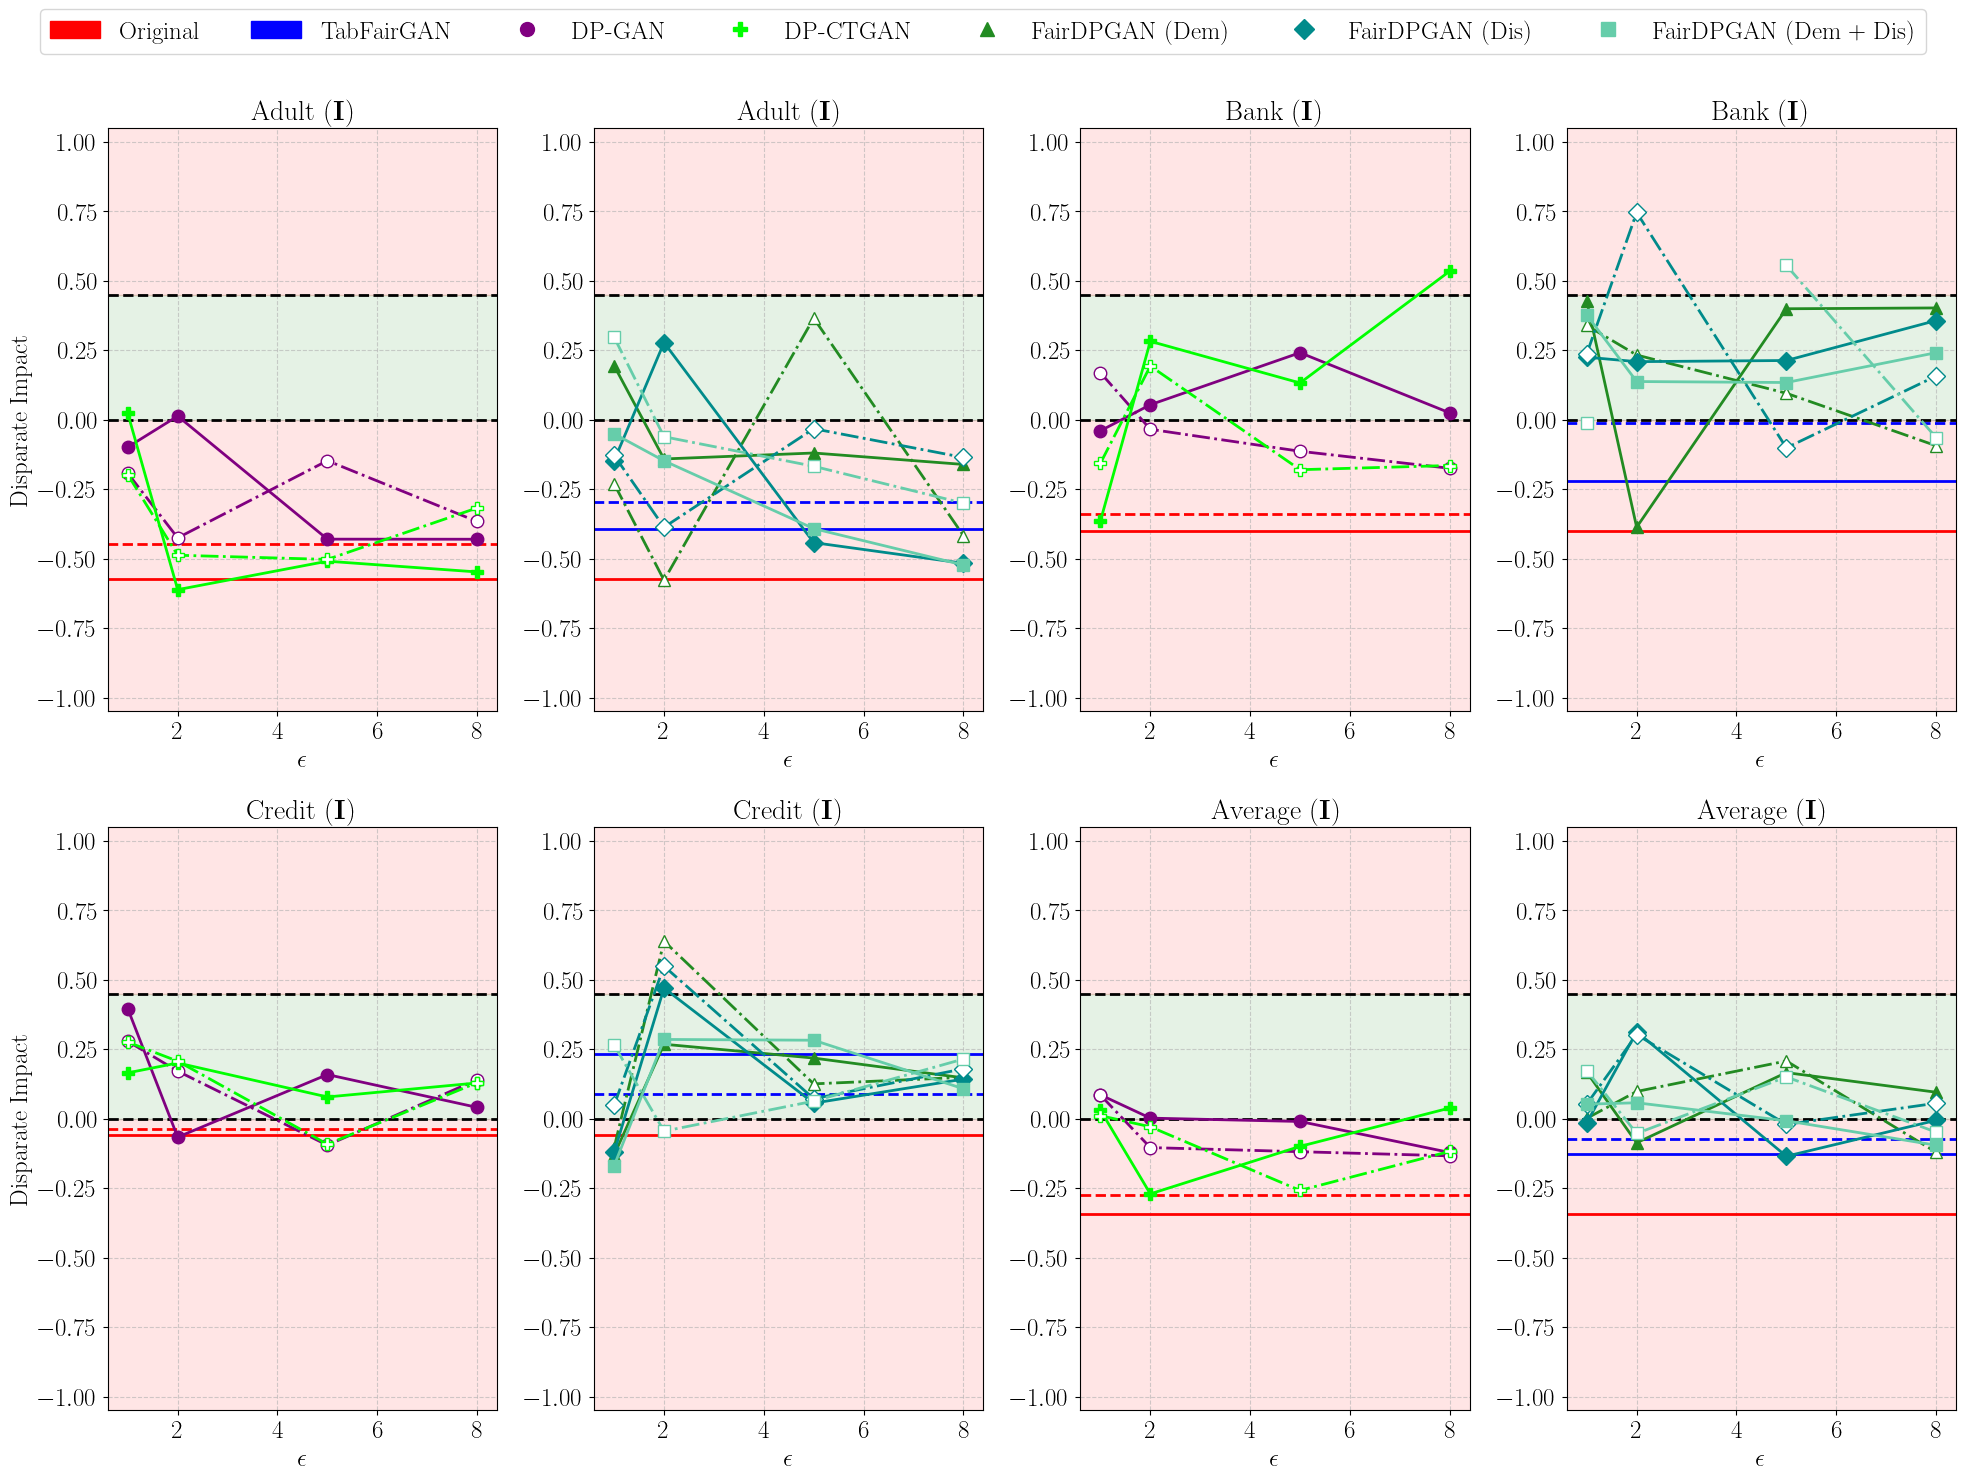

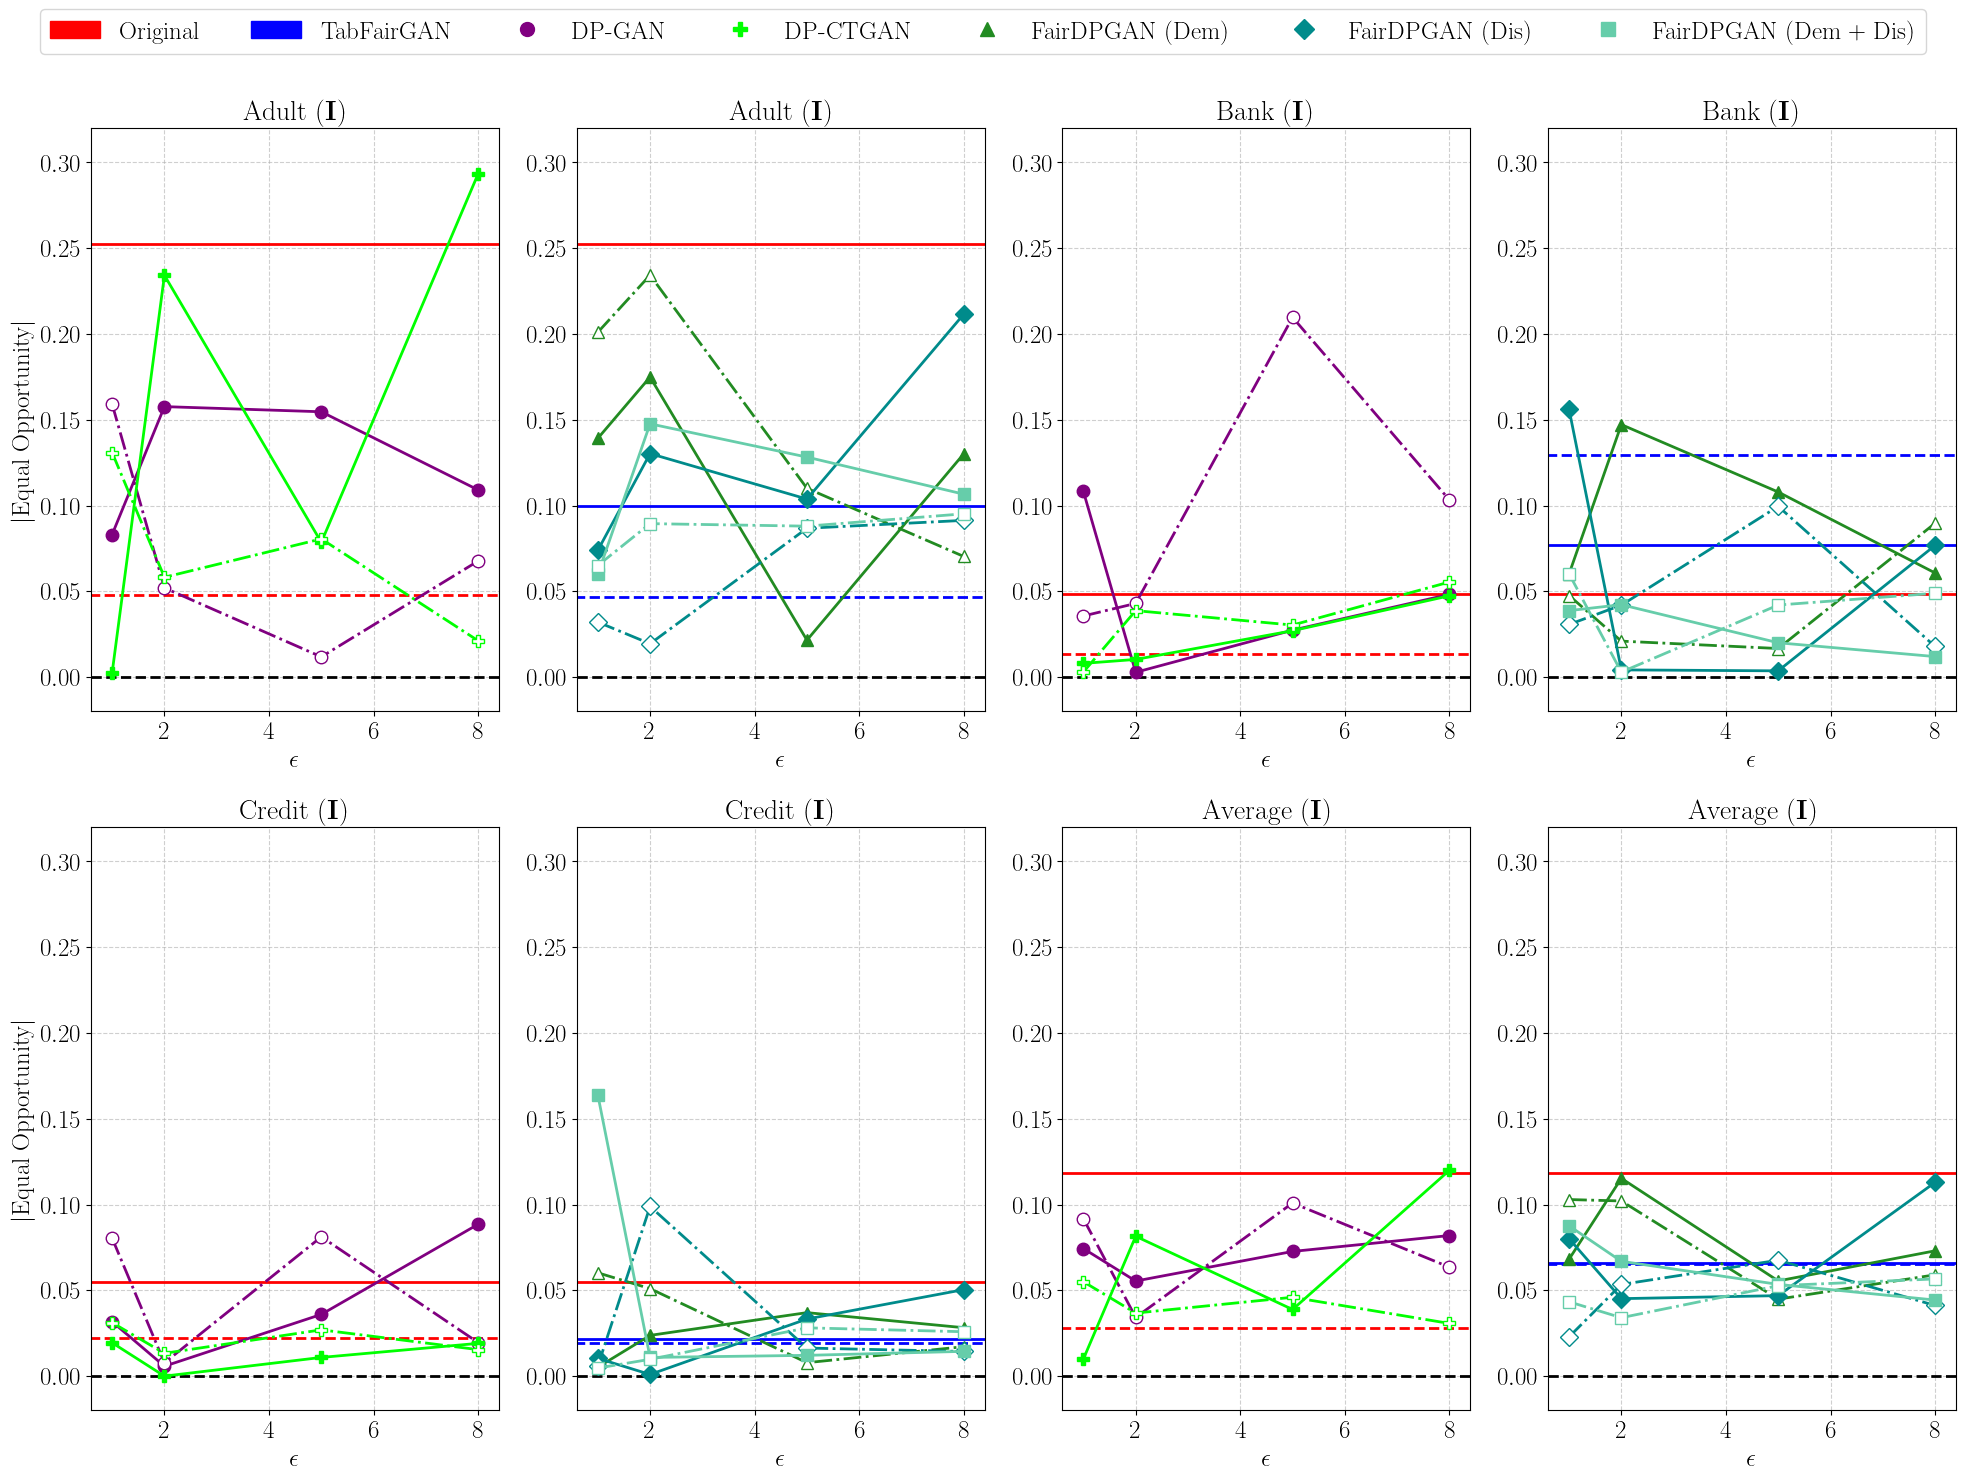

In [73]:
# Plotting fairness metrics of classifiers trained on the 'best' synthetic datasets from all our models.
labels = ["Original", "TabFairGAN", "DP-GAN", "DP-CTGAN", "FairDPGAN (Dem)", "FairDPGAN (Dis)", "FairDPGAN (Dem + Dis)"]
colors = ["red", "blue", "purple", "lime", "forestgreen", "darkcyan", "mediumaquamarine"]
limits = {"dem": (-0.02, 0.35), "dis": (-1.05, 1.05), "eqopp": (-0.02, 0.32)}
fairness_clf = ["dem", "dis", "eqopp"]
fairness_labels = ["Demographic Parity", "Disparate Impact", "Equal Opportunity"]
markers = ["o", "P", "^", "D", "s"]
msize = 9

for f in fairness_clf:
    # Create a figure for the aggregated plot.
    fig, axes = plt.subplots(2, 4, figsize = (20, 15.0))  # 2 x 4 grid
    for c in range(0, 8):
        if c == 0 or c == 1:
            r = 0
            dataset = "Adult"
            results_np = pd.concat([adult_results[f]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF = pd.concat([adult_tabfair_results[f]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP = pd.concat([adult_results_DP[f], adult_results_DP_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results = pd.concat([results_np, results_DP], axis = 1)

            results_DPC = pd.concat([adult_results_DPC[f], adult_results_DPC_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT = pd.concat([results_TF, results_DPC], axis = 1)

            results_fdemDP = pd.concat([adult_results_dem[f], adult_results_dem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

            results_fdisDP = pd.concat([adult_results_dis[f], adult_results_dis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

            results_fdemdiDP = pd.concat([adult_results_demdi[f], adult_results_demdi_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

            # Results without preprocessing.
            results_np_old = pd.concat([adult_nop_results[f]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF_old = pd.concat([adult_tabfair_old[f]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP_old = pd.concat([adult_DP_old[f], adult_DP_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_old = pd.concat([results_np_old, results_DP_old], axis = 1)

            results_DPC_old = pd.concat([adult_DPC_old[f], adult_DPC_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT_old = pd.concat([results_TF_old, results_DPC_old], axis = 1)

            results_fdemDP_old = pd.concat([adult_dem_old[f], adult_dem_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem_old = pd.concat([results_np_old, results_fdemDP_old], axis = 1)

            results_fdisDP_old = pd.concat([adult_dis_old[f], adult_dis_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis_old = pd.concat([results_np_old, results_fdisDP_old], axis = 1)

            results_fdemdiDP_old = pd.concat([adult_demdi_old[f], adult_demdi_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi_old = pd.concat([results_np_old, results_fdemdiDP_old], axis = 1)

        elif c == 2 or c == 3:
            r = 0
            dataset = "Bank"
            results_np = pd.concat([bank_results[f]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF = pd.concat([bank_tabfair_results[f]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP = pd.concat([bank_results_DP[f], bank_results_DP_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results = pd.concat([results_np, results_DP], axis = 1)

            results_DPC = pd.concat([bank_results_DPC[f], bank_results_DPC_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT = pd.concat([results_TF, results_DPC], axis = 1)

            results_fdemDP = pd.concat([bank_results_dem[f], bank_results_dem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

            results_fdisDP = pd.concat([bank_results_dis[f], bank_results_dis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

            results_fdemdiDP = pd.concat([bank_results_demdi[f], bank_results_demdi_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

            # Results without preprocessing.
            results_np_old = pd.concat([bank_nop_results[f]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF_old = pd.concat([bank_tabfair_old[f]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP_old = pd.concat([bank_DP_old[f], bank_DP_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_old = pd.concat([results_np_old, results_DP_old], axis = 1)

            results_DPC_old = pd.concat([bank_DPC_old[f], bank_DPC_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT_old = pd.concat([results_TF_old, results_DPC_old], axis = 1)

            results_fdemDP_old = pd.concat([bank_dem_old[f], bank_dem_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem_old = pd.concat([results_np_old, results_fdemDP_old], axis = 1)

            results_fdisDP_old = pd.concat([bank_dis_old[f], bank_dis_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis_old = pd.concat([results_np_old, results_fdisDP_old], axis = 1)

            results_fdemdiDP_old = pd.concat([bank_demdi_old[f], bank_demdi_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi_old = pd.concat([results_np_old, results_fdemdiDP_old], axis = 1)

        elif c == 4 or c == 5:
            r = 1
            dataset = "Credit"
            results_np = pd.concat([credit_results[f]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF = pd.concat([credit_tabfair_results[f]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP = pd.concat([credit_results_DP[f], credit_results_DP_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results = pd.concat([results_np, results_DP], axis = 1)

            results_DPC = pd.concat([credit_results_DPC[f], credit_results_DPC_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT = pd.concat([results_TF, results_DPC], axis = 1)

            results_fdemDP = pd.concat([credit_results_dem[f], credit_results_dem_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

            results_fdisDP = pd.concat([credit_results_dis[f], credit_results_dis_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

            results_fdemdiDP = pd.concat([credit_results_demdi[f], credit_results_demdi_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

            # Results without preprocessing.
            results_np_old = pd.concat([credit_nop_results[f]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF_old = pd.concat([credit_tabfair_old[f]], axis = 1).set_axis(["TF"], axis = 1)
            
            results_DP_old = pd.concat([credit_DP_old[f], credit_DP_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_old = pd.concat([results_np_old, results_DP_old], axis = 1)

            results_DPC_old = pd.concat([credit_DPC_old[f], credit_DPC_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT_old = pd.concat([results_TF_old, results_DPC_old], axis = 1)

            results_fdemDP_old = pd.concat([credit_dem_old[f], credit_dem_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem_old = pd.concat([results_np_old, results_fdemDP_old], axis = 1)

            results_fdisDP_old = pd.concat([credit_dis_old[f], credit_dis_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis_old = pd.concat([results_np_old, results_fdisDP_old], axis = 1)

            results_fdemdiDP_old = pd.concat([credit_demdi_old[f], credit_demdi_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi_old = pd.concat([results_np_old, results_fdemdiDP_old], axis = 1)
                
        else:
            r = 1
            dataset = "Average"
            results_np = pd.concat([avg_real_results[f]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF = pd.concat([avg_TF_results[f]], axis = 1).set_axis(["TF"], axis = 1)

            results_DP = pd.concat([avg_DP_results[f], avg_DP_results_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results = pd.concat([results_np, results_DP], axis = 1)

            results_DPC = pd.concat([avg_CT_results[f], avg_CT_results_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT = pd.concat([results_TF, results_DPC], axis = 1)

            results_fdemDP = pd.concat([avg_fdem_results[f], avg_fdem_results_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem = pd.concat([results_np, results_fdemDP], axis = 1)

            results_fdisDP = pd.concat([avg_fdis_results[f], avg_fdis_results_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis = pd.concat([results_np, results_fdisDP], axis = 1)

            results_fdemdiDP = pd.concat([avg_fdemdi_results[f], avg_fdemdi_results_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi = pd.concat([results_np, results_fdemdiDP], axis = 1)

            # Results without preprocessing.
            results_np_old = pd.concat([avg_real_old[f]], axis = 1).set_axis(["Real"], axis = 1)
            results_TF_old = pd.concat([avg_TF_old[f]], axis = 1).set_axis(["TF"], axis = 1)

            results_DP_old = pd.concat([avg_DP_old[f], avg_DP_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_old = pd.concat([results_np_old, results_DP_old], axis = 1)

            results_DPC_old = pd.concat([avg_CT_old[f], avg_CT_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_CT_old = pd.concat([results_TF_old, results_DPC_old], axis = 1)

            results_fdemDP_old = pd.concat([avg_fdem_old[f], avg_fdem_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdem_old = pd.concat([results_np_old, results_fdemDP_old], axis = 1)

            results_fdisDP_old = pd.concat([avg_fdis_old[f], avg_fdis_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdis_old = pd.concat([results_np_old, results_fdisDP_old], axis = 1)

            results_fdemdiDP_old = pd.concat([avg_fdemdi_old[f], avg_fdemdi_old_std[f]], axis = 1).set_axis(["mean", "std"], axis = 1).T
            results_fdemdi_old = pd.concat([results_np_old, results_fdemdiDP_old], axis = 1)

        results_all = [results, results_CT, results_fdem, results_fdis, results_fdemdi]
        results_all_old = [results_old, results_CT_old, results_fdem_old, results_fdis_old, results_fdemdi_old]
        
        # Customizing the plot.
        col = fairness_clf.index(f)
        if r == 0:
            ax = axes[r, c] 
        if r == 1:
            ax = axes[r, c - 4]
        ax.set_title(f"{dataset} " + r"($\bf{I}$)")
        ax.set_xlabel("$\epsilon$")
        if c == 0 or c == 4:
            if f == "dis":
                ax.set_ylabel(fairness_labels[col])
            else:
                ax.set_ylabel(f"$|${fairness_labels[col]}$|$")
        ax.set_aspect('auto')
        ax.set_xlim([0.6, 8.4])
        ax.set_ylim(limits[f][0], limits[f][1])
        ax.grid(True, linestyle = '--', alpha = 0.6)
    
        # Plotting a dashed line for the demographic parity and disparate impact parameters.
        ax.axhline(0, 0, 5, ls = "--", c = "black")

        if f == "dis":
            # Plotting another dashed line for the disparate impact parameter.
            ax.axhline(0.45, 0, 5, ls = "--", c = "black")
            # Plotting three rectangular patches for the disparate impact parameter.
            rect1 = mpatches.Rectangle(xy = (-0.5, 0), width = 11.5, height = 0.45, color='green', alpha = 0.1, ec='green')
            ax.add_patch(rect1)
            rect2 = mpatches.Rectangle(xy = (-0.5, 0), width = 11.5, height = -10.5, color='red', alpha = 0.1, ec='red')
            ax.add_patch(rect2)
            rect3 = mpatches.Rectangle(xy = (-0.5, 0.45), width = 11.5, height = 10.5, color='red', alpha = 0.1, ec='red')
            ax.add_patch(rect3)

        # Create lineplots for the current metric: Adult, Bank, Credit & Average.
        for res in range(len(results_all)):
            if res == 0:
                ax.plot([0, 11], [results_all[res].iloc[0][0]]*len([0, 11]), color = colors[res])   # original
                if c % 2 == 0:
                    ax.plot([0, 11], [results_all_old[res].iloc[0][0]]*len([0, 11]), color = colors[res], ls = "--")   # original (old)
                    ax.plot(epsi, results_all[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize)   # DP-GAN
                    ax.plot(epsi, results_all_old[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                            ls = "-.", markerfacecolor = "white",)   # DP-GAN (old)
            elif res == 1:
                if c % 2 != 0:
                    ax.plot([0, 11], [results_all[res].iloc[0][0]]*len([0, 11]), color = colors[res])   # TabFairGAN
                    ax.plot([0, 11], [results_all_old[res].iloc[0][0]]*len([0, 11]), color = colors[res], ls = "--")   # TabFairGAN (old)
                if c % 2 == 0:
                    ax.plot(epsi, results_all[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize)   # DP-CTGAN
                    ax.plot(epsi, results_all_old[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                            ls = "-.", markerfacecolor = "white",)   # DP-CTGAN (old)
            else:
                if c % 2 != 0:
                    ax.plot(epsi, results_all[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                            )   # Fair DP-GANs
                    ax.plot(epsi, results_all_old[res].iloc[0][1:5], color = colors[res + 2], marker = markers[res], markersize = msize,
                            ls = "-.", markerfacecolor = "white",)   # Fair DP-GANs (old)

        if c == 0:
            h_patch = [mpatches.Patch(color = colors[i], label = labels[i]) for i in range(2)]
            h_lines = [mlines.Line2D([], [], color = colors[i], marker = markers[i - 2], label = labels[i], linestyle = 'None',
                        markersize = 10) for i in range(2, len(colors))]
            plt.figlegend(handles = h_patch + h_lines, ncol = 7, loc = "upper center", bbox_to_anchor = (0.5, 1.0))
        
        plt.tight_layout(rect = [0, 0, 1, 0.95])
    plt.show()

## Comparison of GANs' Results for Group Fairness and Utility

In [74]:
#adult_results_dem
#bank_results_dem
#credit_results_dem

#adult_results_dis
#bank_results_dis
#credit_results_dis
avg_fdis_results

#adult_results_demdi
#bank_results_demdi
#credit_results_demdi

,acc,prec,recall,auroc,dem,dis,eqopp
epsi_1,74.292785,35.846514,35.553834,0.580771,0.040406,-0.014368,0.08011
epsi_2,84.734656,22.634306,16.889069,0.554668,0.010268,0.313248,0.04515
epsi_5,85.111344,47.352289,27.662606,0.607797,0.039259,-0.134974,0.04691
epsi_8,87.642539,50.418441,50.831136,0.715499,0.081702,-0.005660,0.11292


In [75]:
#adult_tabfair_results
#bank_tabfair_results
#credit_tabfair_results

#adult_results_DP
#bank_results_DP
#credit_results_DP
avg_DP_results

#adult_results_DPC
#bank_results_DPC
#credit_results_DPC

,acc,prec,recall,auroc,dem,dis,eqopp
epsi_1,71.527169,21.064506,46.648738,0.596358,0.098158,0.085960,0.074340
epsi_2,84.219713,31.978299,22.109039,0.571650,0.024669,0.002242,0.055416
epsi_5,87.292891,50.103090,46.772421,0.697027,0.062008,-0.009785,0.072664
epsi_8,83.709990,46.580165,42.082369,0.666456,0.040963,-0.121480,0.081943
